# Clustering de obras por autor

En este notebook, se realizará un análisis de clustering para agrupar las obras por autor. En concreto, se van a realizar tres experimetos usando diferentes conjuntos de características y diferentes algoritmos de clustering.

En cuanto a los conjuntos de características, se van a usar:

* Solo características estilométricas.
* Solo las palabras funcionales más frecuentes en el texto.
* Una combinación de ambas.

Con respecto a los algoritmos de clustering, utilizaremos:

* K-means
* Agglomerative Clustering
* GaussianMixture

Dado que tenemos las etiquetas de autor, se podrá evaluar la calidad de los clusters obtenidos. El objetivo es ver si estas técnicas de clustering son capaces de agrupar correctamente las obras por autor, lo que indicaría que las características seleccionadas son efectivas para capturar el estilo de cada autor.

In [1]:
import json
import pandas as pd

from itertools import product
from pathlib import Path
from tqdm.auto import tqdm

from whodunit_stylometry.constants import STOPWORDS
from whodunit_stylometry.utils.nlp_utils import build_mfw_features
from whodunit_stylometry.utils.plot_utils import (
    plot_confussion_matrix,
    plot_clusters_2d,
    plot_dendrogram_colored_labels,
)
from whodunit_stylometry.utils.train_utils import (
    run_clustering_experiment,
    evaluate_cluster_errors,
    cluster_author_table,
    errors_by_true_author,
    confusion_pairs,
    evaluate_hierarchical_clustering,
    compare_hierarchical_methods,
)

## Configuración

In [2]:
SEED = 42
TOP_N_MFW = 50
INPUT_PATH = Path("../output/tables")
CORPUS_PATH = Path("../corpus")
FIGS_DIR = Path("../output/figures")
ML_ARTIFACTS_PATH = Path("../artifacts/best_uml_model")
ML_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

## Carga de datos

In [3]:
# Cargamos las métricas previamente calculadas para el corpus
df = pd.read_csv(INPUT_PATH / "corpus_eda_metrics.csv")
print(df.shape)
df.head()

(95, 72)


,file_name,author,title,year,type,detective,genre,language,country,source,...,period_count_per_1000,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000
0,acd-a_study_in_scarlet.txt,A.C. Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.707677,1.975159,0.265887,1.614312,3.969309,0.189919,32.248262,2.032134,4.937896,0.075968
1,acd-tales_of_terror_and_mystery.txt,A.C. Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,...,43.183733,1.033534,0.752682,1.819918,3.089367,0.179745,19.479863,2.909622,5.392350,0.584171
2,acd-the_adventures_of_sherlock_holmes.txt,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.671439,1.554169,0.430859,2.662091,5.678102,0.123102,39.154286,1.346433,5.678102,0.076939
3,acd-the_case_book_of_sherlock_holmes.txt,A.C. Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,57.387639,0.650808,0.233125,3.224898,7.129744,0.437110,41.107733,3.312320,5.235602,0.038854
4,acd-the_hound_of_the_baskervilles.txt,A.C. Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.648868,0.626226,0.222658,2.532738,7.208561,0.264407,38.561628,1.906511,3.687777,0.139161


In [4]:
# Eliminamos la extensión de los nombres de los
# archivos para facilitar su manejo
df["file_name"] = df["file_name"].str[:-4]

In [5]:
# Añadimos la ruta a los archivos tokenizados para cada texto
df["tokens_path"] = df.apply(
    lambda x: CORPUS_PATH / "tokenized/alpha/lower" / x["author_norm"] / f"{x['file_name']}.json", axis=1
)

In [6]:
labels = df["author_norm"].unique().tolist()
print(labels)

['arthur_conan_doyle', 'anna_katharine_green', 'arthur_morrison', 'gilbert_keith_chesterton', 'richard_austin_freeman', 'wilkie_collins']


En este experimento no vamos a usar los datos de entrenamiento y test por separado, sino que vamos a usar el corpus completo para realizar el clustering.

## Selección de características

### Métricas de estilometría

De todas la métricas estilometricas que hemos calculado, nos vamos a quedar con aquellas que no dependen de la longitud del texto, ya que esta podría ser una variable de confusión a la hora de analizar el estilo de autoría. Así, por ejemplo, el número de palabras o caracteres podría estar más relacionado con la longitud del texto que con el estilo del autor.

In [7]:
base_features = [
    "non_alpha_ratio",
    "digit_ratio",
    "whitespace_ratio",
    "non_alpha_token_ratio",
    "avg_sentence_len",
    "median_sentence_len",
    "std_sentence_len",
    "sentences_per_1000_tokens",
    "short_sentence_ratio",
    "long_sentence_ratio",
    "avg_paragraph_len",
    "median_paragraph_len",
    "std_paragraph_len",
    "paragraphs_per_1000_tokens",
    "avg_sentences_per_paragraph",
    "median_sentences_per_paragraph",
    "hapax_ratio",
    "avg_word_len",
    "long_word_ratio",
    "mattr_100",
    "stopword_ratio",
    "punctuation_ratio",
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
]

### Cálculo de MFW

Ahora lo que vamos a hacer es calcular las MFW (*Most Frequent Words*) en nuestro conjunto de datos, ya que estas son una de las características más utilizadas en estilometría para la atribución de autoría. Para ello, vamos a utilizar la función `build_mfw_features` que hemos definido previamente, y vamos a quedarnos con las `TOP_N_MFW` palabras más frecuentes en nuestro corpus.

Luego, vamos a añadir estas MFW como características a nuestro conjunto de datos, y vamos a calcular la frecuencia de cada una de estas palabras en cada texto.

Para construir esta MFW, vamos a utilizar el conjunto de entrenamiento, ya que es el que vamos a utilizar para entrenar nuestro modelo, y queremos evitar cualquier tipo de fuga de información desde el conjunto de test.

A continuación, una vez que tengamos las MFW, usaremos la función `transform_with_mfw` para añadir estas características a nuestro conjunto de datos de test.

In [8]:
# Cargamos los tokens de cada texto para poder calcular las MFW
tokens_by_file = {}

for book in tqdm(df["tokens_path"]):
    tokens = json.load(book.open())
    book_name = Path(book).stem
    tokens_by_file[book_name] = tokens

  0%|          | 0/95 [00:00<?, ?it/s]

In [9]:
mfw, mfw_df = build_mfw_features(
    tokens_by_file=tokens_by_file,
    function_words=STOPWORDS,
    top_n=TOP_N_MFW,
)

mfw_df

,file_name,fw_the,fw_and,fw_to,fw_of,fw_i,fw_a,fw_in,fw_was,fw_he,...,fw_so,fw_an,fw_been,fw_when,fw_or,fw_were,fw_would,fw_out,fw_your,fw_will
0,acd-a_study_in_scarlet,0.057897,0.031080,0.025029,0.027711,0.020445,0.023012,0.016640,0.014921,0.018222,...,0.003667,0.002957,0.003369,0.003232,0.002590,0.003874,0.002819,0.002750,0.001971,0.002177
1,acd-tales_of_terror_and_mystery,0.060438,0.029677,0.024857,0.029466,0.024989,0.023945,0.017196,0.019864,0.012534,...,0.004160,0.004372,0.003777,0.002615,0.002457,0.004108,0.003315,0.002192,0.001625,0.001875
2,acd-the_adventures_of_sherlock_holmes,0.053363,0.028697,0.026092,0.025179,0.028288,0.025074,0.016783,0.013407,0.013997,...,0.004269,0.003157,0.003737,0.003062,0.001883,0.003319,0.003109,0.003062,0.003765,0.002501
3,acd-the_case_book_of_sherlock_holmes,0.049705,0.023166,0.023057,0.022718,0.027325,0.024399,0.015452,0.016395,0.015657,...,0.003905,0.003337,0.003119,0.002648,0.001959,0.002733,0.003567,0.002454,0.004002,0.003156
4,acd-the_hound_of_the_baskervilles,0.056004,0.027371,0.023673,0.026800,0.024396,0.021958,0.015317,0.013501,0.015367,...,0.004102,0.003379,0.003732,0.002404,0.002152,0.003480,0.003245,0.002841,0.003010,0.002993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,wc-the_dead_secret,0.065996,0.028256,0.031283,0.029698,0.016048,0.016112,0.017166,0.010128,0.008975,...,0.002808,0.002242,0.002716,0.004519,0.002115,0.002992,0.002037,0.002673,0.003360,0.002688
91,wc-the_haunted_hotel,0.071443,0.020907,0.033315,0.031488,0.015633,0.016904,0.020303,0.011677,0.013933,...,0.001938,0.002319,0.002828,0.003034,0.001716,0.002590,0.001271,0.002288,0.003225,0.002717
92,wc-the_law_and_the_lady,0.059509,0.023551,0.033818,0.028692,0.033021,0.017301,0.020218,0.012153,0.013763,...,0.002076,0.002316,0.002281,0.003503,0.002288,0.002796,0.001921,0.002104,0.004237,0.002549
93,wc-the_moonstone,0.062092,0.023965,0.034904,0.028490,0.029589,0.017743,0.020951,0.012033,0.010736,...,0.001682,0.002397,0.002625,0.003668,0.002017,0.002169,0.002011,0.003268,0.003587,0.002630


In [10]:
# Mostramos algunas de las MFW que hemos obtenido
print(mfw[:20])

['the', 'and', 'to', 'of', 'i', 'a', 'in', 'was', 'he', 'that', 'it', 'you', 'his', 'had', 'with', 'as', 'her', 'my', 'for', 'at']


## Construcción de los DataFrames de entrenamiento y test para los experimentos

Vamos a ejecutar 3 experimentos, cada uno con un conjunto de características diferente:

* Solo las métricas de estilometría
* Solo las MFW
* Las métricas de estilometría + las MFW

Para ello necesitamos construir tres DataFrames, cada uno con las características correspondientes a cada experimento.

### Dataset base

Este dataset base lo vamos a utilizar para el experimento de solo las métricas de estilometría.

In [11]:
# Añadimos `file_name` como identificador único y
# `author_norm` como etiqueta de salida
base_df = df[["file_name", "author_norm"] + base_features].copy()
print("Base dataset shape:", base_df.shape)

Base dataset shape: (95, 35)


### Dataset de palabras funcionales más frecuentes (MFW)

Este dataset lo vamos a utilizar para el experimento de solo las MFW y va a estar compuesto por las características correspondientes a las `TOP_N_MFW` palabras más frecuentes en nuestro corpus, calculadas a partir del conjunto de entrenamiento.

De nuevo, añadimos `file_name`como idntificador de cada texto, y `author_norm` como variable objetivo.

In [12]:
fw_cols = [c for c in mfw_df.columns if c.startswith("fw_")]

fw_df = base_df[["file_name", "author_norm"]].merge(mfw_df[["file_name"] + fw_cols], on="file_name", how="inner")
print("Dataset with MFW shape:", fw_df.shape)

Dataset with MFW shape: (95, 52)


### Dataset combinado (base + MFW)

Este dataset lo vamos a utilizar para el experimento de las métricas de estilometría + las MFW, y va a estar compuesto por todas las características del dataset base (métricas de estilometría) y las características correspondientes a las `TOP_N_MFW` palabras más frecuentes en nuestro corpus.

In [13]:
combined_df = base_df.merge(mfw_df[["file_name"] + fw_cols], on="file_name", how="inner")
print("Combined dataset shape:", combined_df.shape)

Combined dataset shape: (95, 85)


## Ejecutar experimentos de clustering

A continuación, vamos a ejecutar los tres experimentos de clustering usando la función `run_clustering_experiment` que hemos definido previamente. Esta función se encarga de ejecutar el algoritmo de clustering seleccionado, asignar cada texto a un cluster, y evaluar la calidad de los clusters obtenidos en función de las etiquetas de autor.

Los algoritmos de clustering que vamos a utilizar son:

- **K-means**. K-means es un algoritmo de clustering particional que busca dividir los datos en $k$ grupos, minimizando la distancia de cada punto al centroide de su clúster. Es eficiente y fácil de interpretar, aunque requiere fijar previamente el número de clústeres, 6 en nuestro caso, y suele funcionar mejor cuando los grupos tienen forma aproximadamente esférica y tamaños similares.
- **Agglomerative Clustering**. Agglomerative Clustering es un método jerárquico que comienza considerando cada observación como un clúster independiente y va fusionando progresivamente los grupos más cercanos. Permite analizar la estructura jerárquica de los datos mediante un dendrograma y no necesita asumir una forma concreta de los clústeres, aunque puede ser más costoso computacionalmente en datasets grandes.
- **GaussianMixture**. GaussianMixture modela los datos como una combinación de varias distribuciones gaussianas, asignando a cada punto una probabilidad de pertenencia a cada clúster. A diferencia de K-means, permite capturar clústeres con formas elípticas y ofrece una asignación probabilística, aunque requiere elegir el número de componentes y puede ser sensible a la inicialización.

In [14]:
# Experimento con solo las features estilométricas
base_cluster_result = run_clustering_experiment(
    data=base_df, feature_cols=base_features, label_col="author_norm", file_col="file_name", seed=SEED
)

# Experimento con solo las MFW
fw_cluster_result = run_clustering_experiment(
    data=fw_df, feature_cols=fw_cols, label_col="author_norm", file_col="file_name", seed=SEED
)

# Experimento con las features estilométricas + MFW
combined_cluster_result = run_clustering_experiment(
    data=combined_df, feature_cols=base_features + fw_cols, label_col="author_norm", file_col="file_name", seed=SEED
)

In [15]:
# Concatenamos los resultados de los tres experimentos
# en un solo DataFrame para facilitar su comparación
summary_clustering_df = pd.concat(
    [
        base_cluster_result["results"].assign(experiment="base_features"),
        fw_cluster_result["results"].assign(experiment="function_words"),
        combined_cluster_result["results"].assign(experiment="combined_features"),
    ],
    axis=0,
)

summary_clustering_df = summary_clustering_df[
    ["experiment", "model", "n_clusters", "silhouette", "ARI", "NMI", "homogeneity", "completeness", "v_measure"]
].sort_values(["ARI", "NMI", "silhouette"], ascending=False)

summary_clustering_df

,experiment,model,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,function_words,agglomerative,6,0.238272,0.919022,0.927689,0.899107,0.958148,0.927689
1,function_words,kmeans,6,0.238758,0.896996,0.902224,0.874426,0.931846,0.902224
0,combined_features,agglomerative,6,0.214542,0.866496,0.858151,0.837657,0.879673,0.858151
1,combined_features,kmeans,6,0.224052,0.743291,0.750163,0.721267,0.781471,0.750163
2,combined_features,gmm,6,0.126561,0.713476,0.770282,0.741138,0.801812,0.770282
0,base_features,agglomerative,6,0.202401,0.706897,0.779033,0.790737,0.767669,0.779033
2,function_words,gmm,6,0.193575,0.704576,0.850242,0.877398,0.824717,0.850242
1,base_features,kmeans,6,0.221992,0.680293,0.705687,0.718635,0.693196,0.705687
2,base_features,gmm,6,0.181203,0.458535,0.600020,0.615131,0.585634,0.600020


Las métricas de evaluación que vamos a utilizar para evaluar la calidad de los clusters obtenidos son:

- **Silhouette**. La métrica *silhouette* evalúa qué tan bien separado y compacto está cada clúster comparando la distancia media de un punto con los puntos de su propio clúster frente a los de otros clústeres. Sus valores van de -1 a 1, donde valores cercanos a 1 indican clústeres bien definidos, valores cercanos a 0 indican solapamiento y valores negativos sugieren asignaciones incorrectas.
- **ARI**. El *Adjusted Rand Index* compara las etiquetas de clustering obtenidas con unas etiquetas reales, midiendo hasta qué punto las parejas de puntos se agrupan de forma consistente en ambas particiones. Está ajustado por azar, por lo que valores cercanos a 1 indican una coincidencia alta, mientras que valores cercanos a 0 indican un resultado similar al aleatorio.
- **NMI**. La *Normalized Mutual Information* mide la cantidad de información compartida entre las etiquetas reales y las etiquetas generadas por el algoritmo de clustering. Su valor está normalizado entre 0 y 1, donde 1 indica una correspondencia perfecta entre ambas asignaciones y 0 indica independencia entre ellas.
- **Homogeneity**. La métrica de *homogeneity* evalúa si cada clúster contiene principalmente muestras de una única clase real. Un valor alto indica que los clústeres son “puros”, es decir, que no mezclan muchas clases diferentes dentro del mismo grupo.
- **Completeness**. La *completeness* mide si todas las muestras que pertenecen a una misma clase real han sido asignadas al mismo clúster. Un valor alto indica que cada clase está bien concentrada en un único grupo, aunque esto no garantiza necesariamente que los clústeres sean puros.
- **V-measure**. La *V-measure* combina *homogeneity* y *completeness* mediante una media armónica, ofreciendo una medida equilibrada entre pureza de los clústeres y capacidad para agrupar correctamente cada clase. Su valor va de 0 a 1, donde valores más altos indican una mejor correspondencia global entre los clústeres y las etiquetas reales.

## Tablas de contingencia clusters vs etiquetas de autor

Ahora vamos a quedarnos con el resultado del mejor modelo de cada experimento, es decir, con el modelo que haya obtenido la mejor puntuación en la métrica de evaluación seleccionada (en este caso, el ARI), y vamos a crear una tabla de contingencia entre los clusters obtenidos y las etiquetas de autor para analizar en detalle los errores cometidos por el modelo.

### Features estilométricas

In [16]:
# Tabla de contingencia para el experimento con features estilométricas
best_base_model = base_cluster_result["results"].iloc[0]["model"]
base_cluster_author_table = cluster_author_table(base_cluster_result["assignments"][best_base_model])
base_cluster_author_table

author_norm,anna_katharine_green,arthur_conan_doyle,arthur_morrison,gilbert_keith_chesterton,richard_austin_freeman,wilkie_collins
cluster,,,,,,
0,1,11,6,0,0,0
1,28,0,0,1,0,0
2,0,0,0,0,0,10
3,5,1,0,0,1,0
4,0,0,0,3,14,0
5,0,0,0,14,0,0


### Features MFW

In [17]:
# Tabla de contingencia para el experimento con MFW
best_fw_model = fw_cluster_result["results"].iloc[0]["model"]
fw_cluster_author_table = cluster_author_table(fw_cluster_result["assignments"][best_fw_model])
fw_cluster_author_table

author_norm,anna_katharine_green,arthur_conan_doyle,arthur_morrison,gilbert_keith_chesterton,richard_austin_freeman,wilkie_collins
cluster,,,,,,
0,34,1,0,0,0,0
1,0,0,5,0,15,0
2,0,11,0,0,0,0
3,0,0,0,18,0,0
4,0,0,1,0,0,0
5,0,0,0,0,0,10


### Features combinadas

In [18]:
# Tabla de contingencia para el experimento con features combinadas
best_combined_model = combined_cluster_result["results"].iloc[0]["model"]
combined_cluster_author_table = cluster_author_table(combined_cluster_result["assignments"][best_combined_model])
combined_cluster_author_table

author_norm,anna_katharine_green,arthur_conan_doyle,arthur_morrison,gilbert_keith_chesterton,richard_austin_freeman,wilkie_collins
cluster,,,,,,
0,0,1,0,15,1,0
1,0,11,5,0,0,0
2,0,0,0,0,0,10
3,34,0,0,0,0,0
4,0,0,0,3,14,0
5,0,0,1,0,0,0


## Análisis de los errores cometidos por el modelo

Aquí vamos a analizar en detalle los errores cometidos por el modelo, es decir, aquellos textos que han sido asignados a un cluster diferente al de su autor real. Para ello, vamos a revisar las tablas de contingencia obtenidas en el paso anterior y vamos a identificar cuáles son los textos que han sido asignados a un cluster incorrecto.

### Features estilométricas

In [19]:
best_base_model = base_cluster_result["results"].iloc[0]["model"]
base_eval = evaluate_cluster_errors(
    base_cluster_result["assignments"][best_base_model],
    label_col="author_norm",
    cluster_col="cluster",
    file_col="file_name",
)

print("========= RESULTADOS DEL MODELO CON FEATURES ESTILOMÉTRICAS =========")
print(f"Accuracy: {base_eval['accuracy_after_mapping']:.4f}")
print("Errores:")
base_eval["errors_df"]

========= RESULTADOS DEL MODELO CON FEATURES ESTILOMÉTRICAS =========
Accuracy: 0.8632
Errores:


,file_name,author_norm,cluster,pred_author_from_cluster
43,akg-three_thousand_dollars,anna_katharine_green,0,arthur_conan_doyle
11,acd-the_white_company,arthur_conan_doyle,3,anna_katharine_green
46,am-adventures_of_martin_hewitt,arthur_morrison,0,arthur_conan_doyle
47,am-chronicles_of_martin_hewitt,arthur_morrison,0,arthur_conan_doyle
48,am-martin_hewitt_investigator,arthur_morrison,0,arthur_conan_doyle
49,am-the_dorrington_deed_box,arthur_morrison,0,arthur_conan_doyle
51,am-the_hole_in_the_wall,arthur_morrison,0,arthur_conan_doyle
50,am-the_red_triangle,arthur_morrison,0,arthur_conan_doyle
55,gkc-the_donnington_affair,gilbert_keith_chesterton,1,anna_katharine_green
54,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,4,richard_austin_freeman


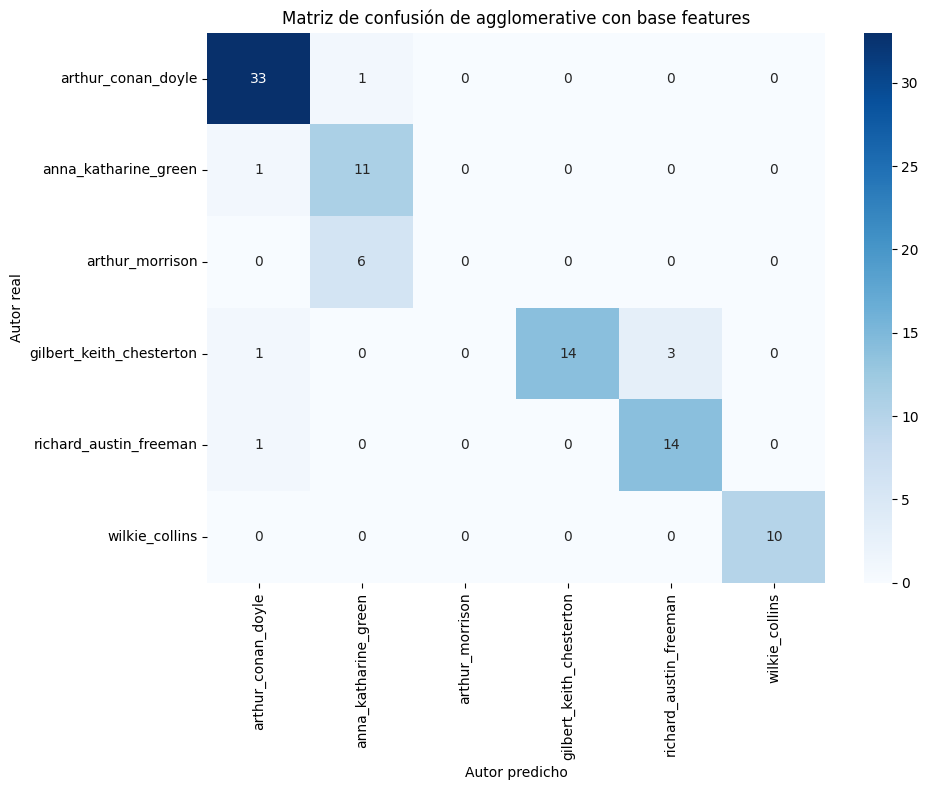

In [20]:
plot_confussion_matrix(
    cm=base_eval["confusion_matrix"], labels=labels, model_name=best_base_model, features="base features"
)

### Features MFW

In [21]:
best_fw_model = fw_cluster_result["results"].iloc[0]["model"]
fw_eval = evaluate_cluster_errors(
    fw_cluster_result["assignments"][best_fw_model],
    label_col="author_norm",
    cluster_col="cluster",
    file_col="file_name",
)

print("========= RESULTADOS DEL MODELO CON FEATURES MFW =========")
print(f"Accuracy: {fw_eval['accuracy_after_mapping']:.4f}")
print("Errores:")
fw_eval["errors_df"]

========= RESULTADOS DEL MODELO CON FEATURES MFW =========
Accuracy: 0.9368
Errores:


,file_name,author_norm,cluster,pred_author_from_cluster
11,acd-the_white_company,arthur_conan_doyle,0,anna_katharine_green
46,am-adventures_of_martin_hewitt,arthur_morrison,1,richard_austin_freeman
47,am-chronicles_of_martin_hewitt,arthur_morrison,1,richard_austin_freeman
48,am-martin_hewitt_investigator,arthur_morrison,1,richard_austin_freeman
49,am-the_dorrington_deed_box,arthur_morrison,1,richard_austin_freeman
50,am-the_red_triangle,arthur_morrison,1,richard_austin_freeman


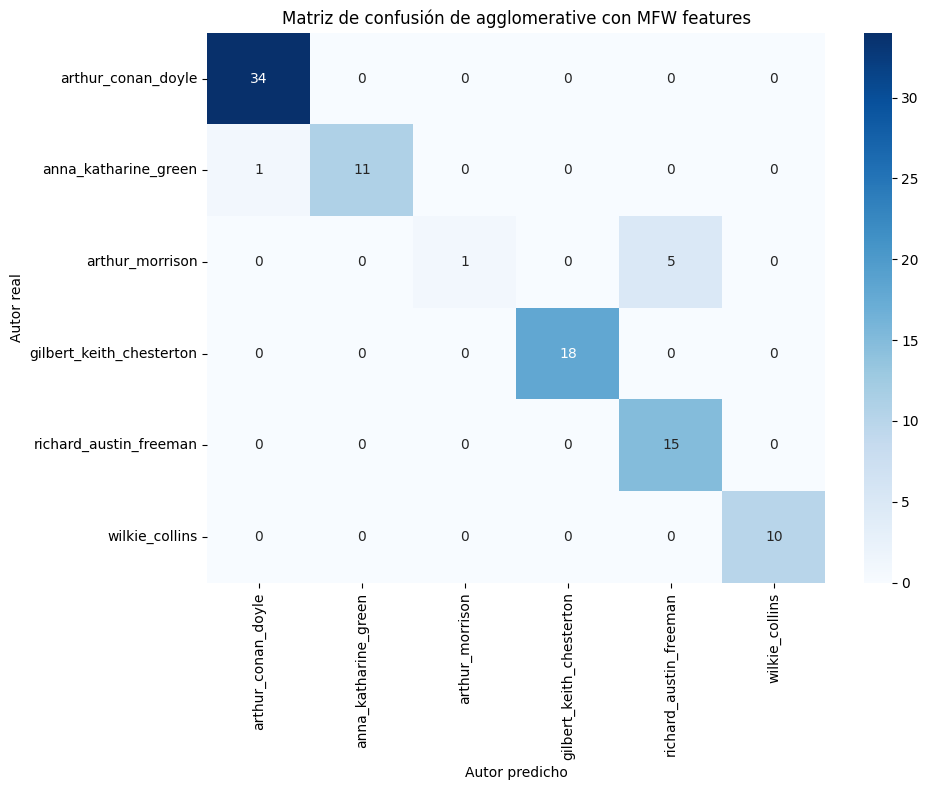

In [22]:
plot_confussion_matrix(cm=fw_eval["confusion_matrix"], labels=labels, model_name=best_fw_model, features="MFW features")

### Features combinadas

In [23]:
best_combined_model = combined_cluster_result["results"].iloc[0]["model"]
combined_eval = evaluate_cluster_errors(
    combined_cluster_result["assignments"][best_combined_model],
    label_col="author_norm",
    cluster_col="cluster",
    file_col="file_name",
)

print("========= RESULTADOS DEL MODELO CON FEATURES COMBINADAS =========")
print(f"Accuracy: {combined_eval['accuracy_after_mapping']:.4f}")
print("Errores:")
combined_eval["errors_df"]

========= RESULTADOS DEL MODELO CON FEATURES COMBINADAS =========
Accuracy: 0.8947
Errores:


,file_name,author_norm,cluster,pred_author_from_cluster
11,acd-the_white_company,arthur_conan_doyle,0,gilbert_keith_chesterton
46,am-adventures_of_martin_hewitt,arthur_morrison,1,arthur_conan_doyle
47,am-chronicles_of_martin_hewitt,arthur_morrison,1,arthur_conan_doyle
48,am-martin_hewitt_investigator,arthur_morrison,1,arthur_conan_doyle
49,am-the_dorrington_deed_box,arthur_morrison,1,arthur_conan_doyle
50,am-the_red_triangle,arthur_morrison,1,arthur_conan_doyle
54,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,4,richard_austin_freeman
59,gkc-the_man_who_was_thursday,gilbert_keith_chesterton,4,richard_austin_freeman
61,gkc-the_napoleon_of_notting_hill,gilbert_keith_chesterton,4,richard_austin_freeman
78,raf-the_golden_pool,richard_austin_freeman,0,gilbert_keith_chesterton


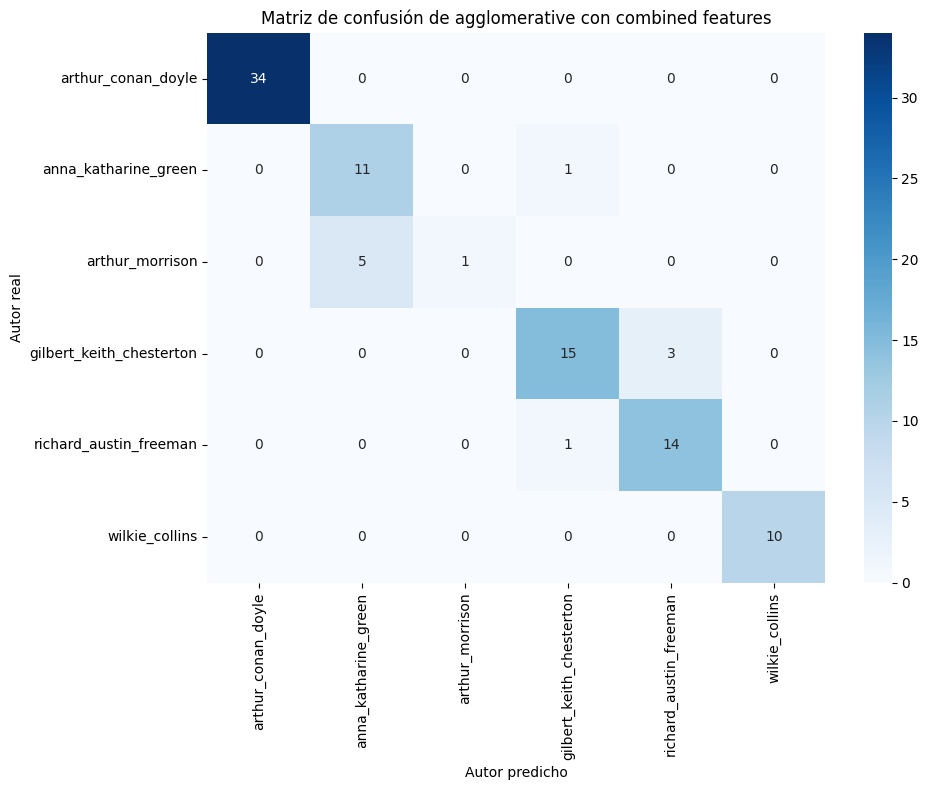

In [24]:
plot_confussion_matrix(
    cm=combined_eval["confusion_matrix"], labels=labels, model_name=best_combined_model, features="combined features"
)

## Comparativa del rendimiento de los modelos

In [25]:
comparison_errors = pd.DataFrame(
    [
        {
            "experiment": "base_features",
            "model": best_base_model,
            "accuracy_after_mapping": base_eval["accuracy_after_mapping"],
            "n_errors": len(base_eval["errors_df"]),
        },
        {
            "experiment": "mfw",
            "model": best_fw_model,
            "accuracy_after_mapping": fw_eval["accuracy_after_mapping"],
            "n_errors": len(fw_eval["errors_df"]),
        },
        {
            "experiment": "combined",
            "model": best_combined_model,
            "accuracy_after_mapping": combined_eval["accuracy_after_mapping"],
            "n_errors": len(combined_eval["errors_df"]),
        },
    ]
)

comparison_errors.sort_values("accuracy_after_mapping", ascending=False)

,experiment,model,accuracy_after_mapping,n_errors
1,mfw,agglomerative,0.936842,6
2,combined,agglomerative,0.894737,10
0,base_features,agglomerative,0.863158,13


Hagamos ahora un recuento de los errores cometidos por cada modelo, es decir, el número de textos que han sido asignados a un cluster diferente al de su autor real.

In [26]:
print("====== ERRORES MODELO CON FEATURES ESTILOMÉTRICAS ======")
errors_by_true_author(base_eval)

====== ERRORES MODELO CON FEATURES ESTILOMÉTRICAS ======


,total_works,correct,errors,error_rate
author_norm,,,,
arthur_morrison,6,0,6,1.000000
gilbert_keith_chesterton,18,14,4,0.222222
arthur_conan_doyle,12,11,1,0.083333
richard_austin_freeman,15,14,1,0.066667
anna_katharine_green,34,33,1,0.029412
wilkie_collins,10,10,0,0.000000


In [27]:
print("====== ERRORES MODELO CON FEATURES MFW ======")
errors_by_true_author(fw_eval)

====== ERRORES MODELO CON FEATURES MFW ======


,total_works,correct,errors,error_rate
author_norm,,,,
arthur_morrison,6,1,5,0.833333
arthur_conan_doyle,12,11,1,0.083333
anna_katharine_green,34,34,0,0.000000
gilbert_keith_chesterton,18,18,0,0.000000
richard_austin_freeman,15,15,0,0.000000
wilkie_collins,10,10,0,0.000000


In [28]:
print("====== ERRORES MODELO CON FEATURES COMBINADAS ======")
errors_by_true_author(combined_eval)

====== ERRORES MODELO CON FEATURES COMBINADAS ======


,total_works,correct,errors,error_rate
author_norm,,,,
arthur_morrison,6,1,5,0.833333
gilbert_keith_chesterton,18,15,3,0.166667
arthur_conan_doyle,12,11,1,0.083333
richard_austin_freeman,15,14,1,0.066667
anna_katharine_green,34,34,0,0.000000
wilkie_collins,10,10,0,0.000000


La siguiente tabla muestra con qué otro autor ha sido confundido cada texto, es decir, a qué cluster ha sido asignado cada texto y cuál es el autor real de ese texto.

In [29]:
print("====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES ESTILOMÉTRICAS ======")
confusion_pairs(base_eval).head(20)

====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES ESTILOMÉTRICAS ======


,author_norm,pred_author_from_cluster,n_errors
2,arthur_morrison,arthur_conan_doyle,6
4,gilbert_keith_chesterton,richard_austin_freeman,3
1,arthur_conan_doyle,anna_katharine_green,1
0,anna_katharine_green,arthur_conan_doyle,1
3,gilbert_keith_chesterton,anna_katharine_green,1
5,richard_austin_freeman,anna_katharine_green,1


In [30]:
print("====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES MFW ======")
confusion_pairs(fw_eval).head(20)

====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES MFW ======


,author_norm,pred_author_from_cluster,n_errors
1,arthur_morrison,richard_austin_freeman,5
0,arthur_conan_doyle,anna_katharine_green,1


In [31]:
print("====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES COMBINADAS ======")
confusion_pairs(combined_eval).head(20)

====== PAREJAS DE AUTORES CONFUNDIDOS MODELO CON FEATURES COMBINADAS ======


,author_norm,pred_author_from_cluster,n_errors
1,arthur_morrison,arthur_conan_doyle,5
2,gilbert_keith_chesterton,richard_austin_freeman,3
0,arthur_conan_doyle,gilbert_keith_chesterton,1
3,richard_austin_freeman,gilbert_keith_chesterton,1


Analicemos ahora cómo cada obra ha sido asignada a los clústeres según los diferentes modelos, si lo ha sido siempre asignada al clúster correcto, siempre asignada a un clúster incorrecto, o si ha sido asignada a un clúster correcto en algunos modelos y a un clúster incorrecto en otros modelos.

In [32]:
base_errors_files = set(base_eval["errors_df"]["file_name"])
fw_errors_files = set(fw_eval["errors_df"]["file_name"])
combined_errors_files = set(combined_eval["errors_df"]["file_name"])

comparison_by_work = pd.DataFrame(
    {
        "file_name": sorted(set(base_cluster_result["assignments"][best_base_model]["file_name"])),
    }
)

comparison_by_work["error_base"] = df["file_name"].isin(base_errors_files)
comparison_by_work["error_mfw"] = df["file_name"].isin(fw_errors_files)
comparison_by_work["error_combined"] = df["file_name"].isin(combined_errors_files)

comparison_by_work.head(20)

,file_name,error_base,error_mfw,error_combined
0,acd-a_study_in_scarlet,False,False,False
1,acd-tales_of_terror_and_mystery,False,False,False
2,acd-the_adventures_of_sherlock_holmes,False,False,False
3,acd-the_case_book_of_sherlock_holmes,False,False,False
4,acd-the_hound_of_the_baskervilles,False,False,False
5,acd-the_lost_world,False,False,False
6,acd-the_memoirs_of_sherlock_holmes,False,False,False
7,acd-the_poison_belt,False,False,False
8,acd-the_return_of_sherlock_holmes,False,False,False
9,acd-the_sign_of_the_four,False,False,False


In [33]:
comparison_by_work[["error_base", "error_mfw", "error_combined"]].value_counts().reset_index(name="count")

,error_base,error_mfw,error_combined,count
0,False,False,False,82
1,True,True,True,6
2,True,False,True,4
3,True,False,False,3


Vemos que la mayoría de las obras siempre se asignan al clúster correcto, independientemente del modelo que usemos, mientras que hay 5 que siempre se asignan a un clúster incorrecto.

In [34]:
comparison_by_work[comparison_by_work[["error_base", "error_mfw", "error_combined"]].all(axis=1)]

,file_name,error_base,error_mfw,error_combined
11,acd-the_white_company,True,True,True
46,am-adventures_of_martin_hewitt,True,True,True
47,am-chronicles_of_martin_hewitt,True,True,True
48,am-martin_hewitt_investigator,True,True,True
49,am-the_dorrington_deed_box,True,True,True
50,am-the_hole_in_the_wall,True,True,True


Cinco de las obras de Arthur Morrison siempre se asignan a un clúster incorrecto. Dado que este es el autor con menos obras en el corpus, es posible que el modelo no haya sido capaz de aprender un patrón estilístico claro para este autor, lo que ha llevado a que sus obras sean asignadas a clústeres incorrectos.

## Visualización de los clusters obtenidos

### Clústeres con features estilométricas

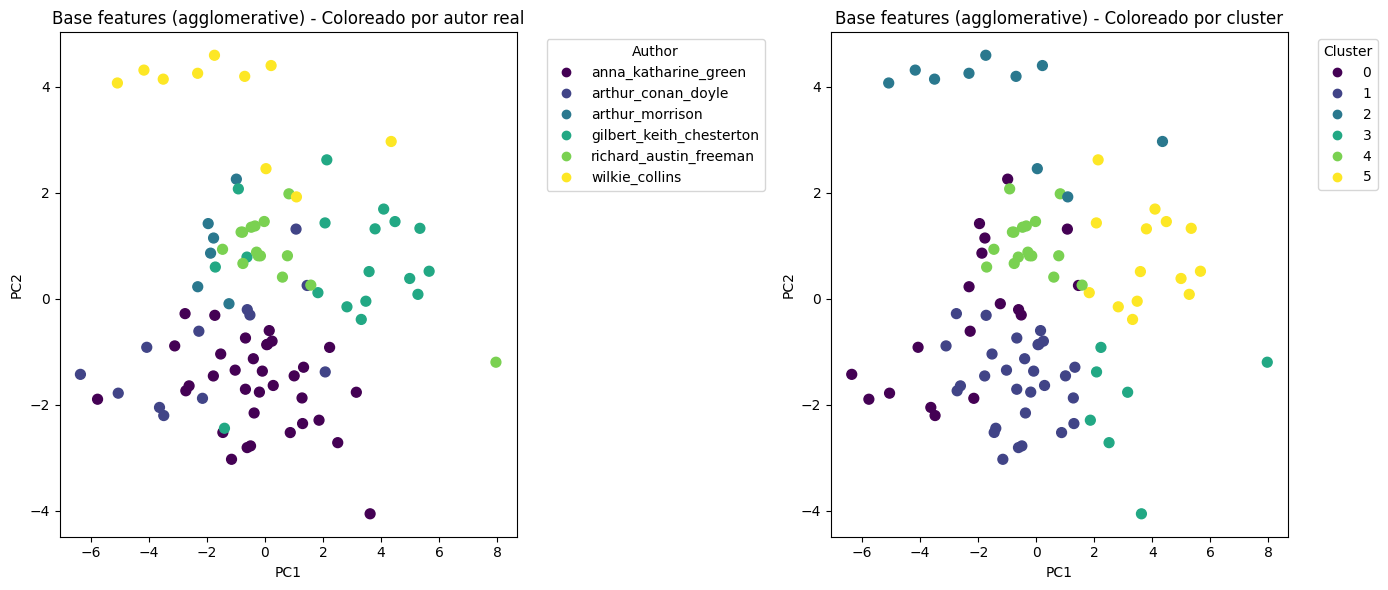

In [35]:
base_clusters = base_cluster_result["assignments"][best_base_model]["cluster"].values

plot_clusters_2d(
    X_scaled=base_cluster_result["X_scaled"],
    y_true=base_cluster_result["y_true"],
    clusters=base_clusters,
    title_prefix=f"Base features ({best_base_model})",
    method="pca",
    seed=SEED,
)

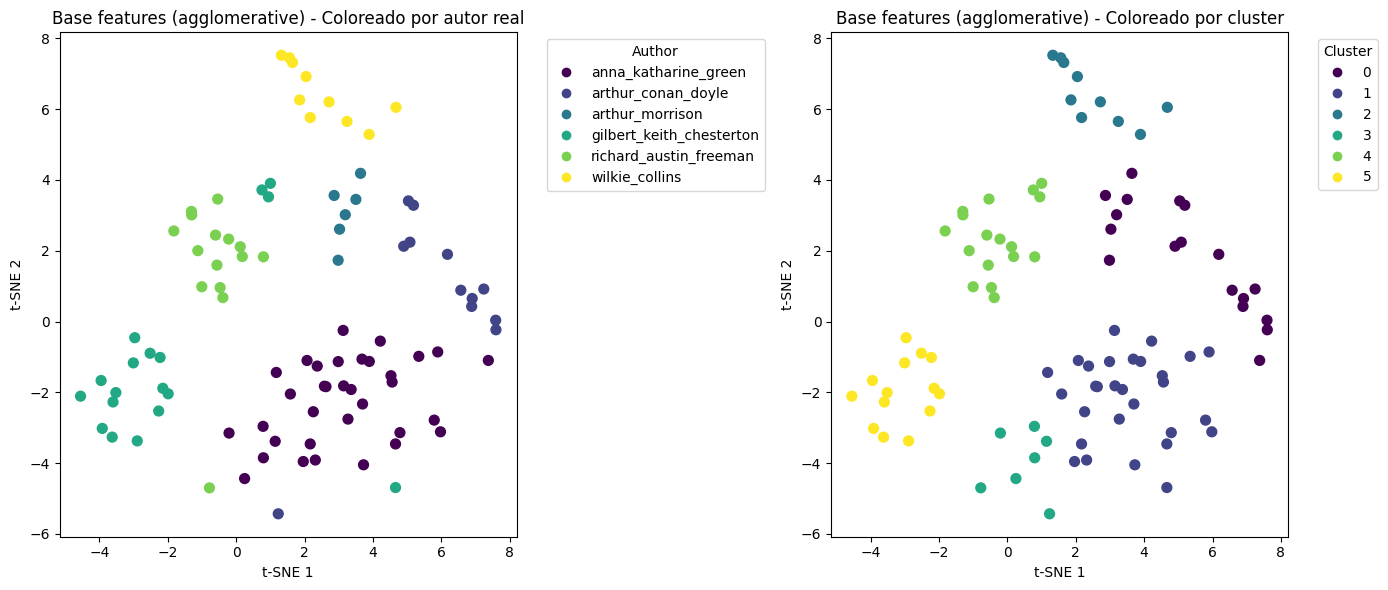

In [36]:
plot_clusters_2d(
    X_scaled=base_cluster_result["X_scaled"],
    y_true=base_cluster_result["y_true"],
    clusters=base_clusters,
    title_prefix=f"Base features ({best_base_model})",
    method="tsne",
    seed=SEED,
)

### Clústeres con features MFW

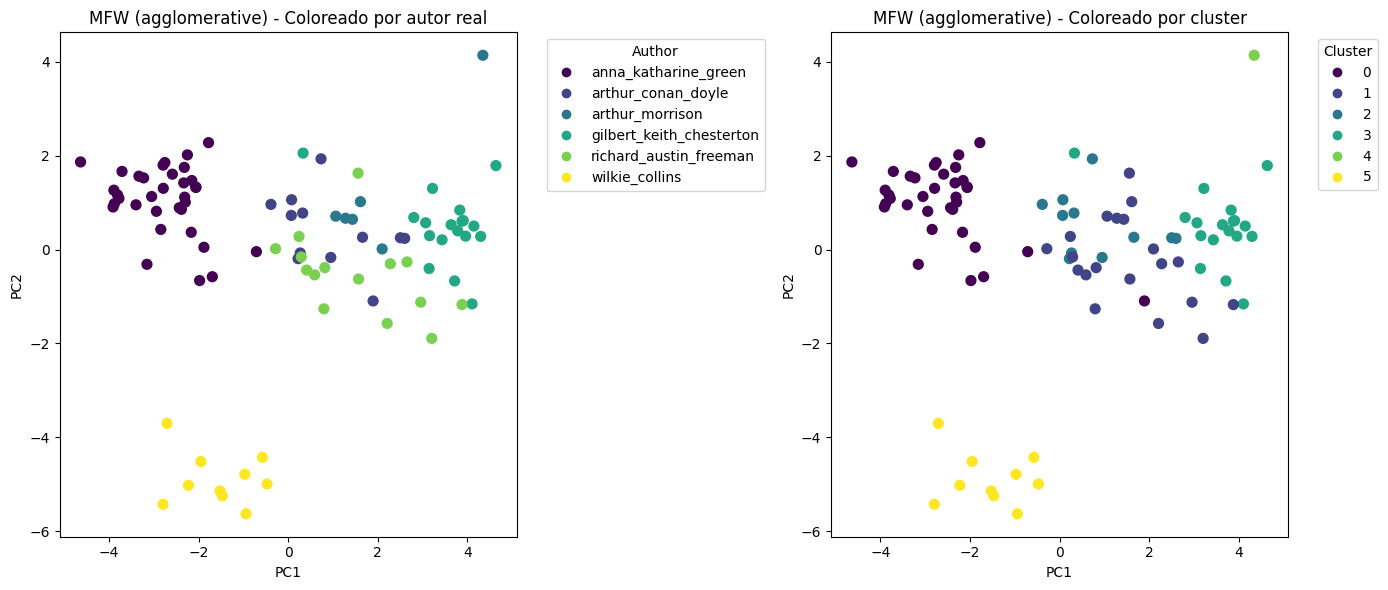

In [37]:
fw_clusters = fw_cluster_result["assignments"][best_fw_model]["cluster"].values

plot_clusters_2d(
    X_scaled=fw_cluster_result["X_scaled"],
    y_true=fw_cluster_result["y_true"],
    clusters=fw_clusters,
    title_prefix=f"MFW ({best_fw_model})",
    method="pca",
    seed=SEED,
)

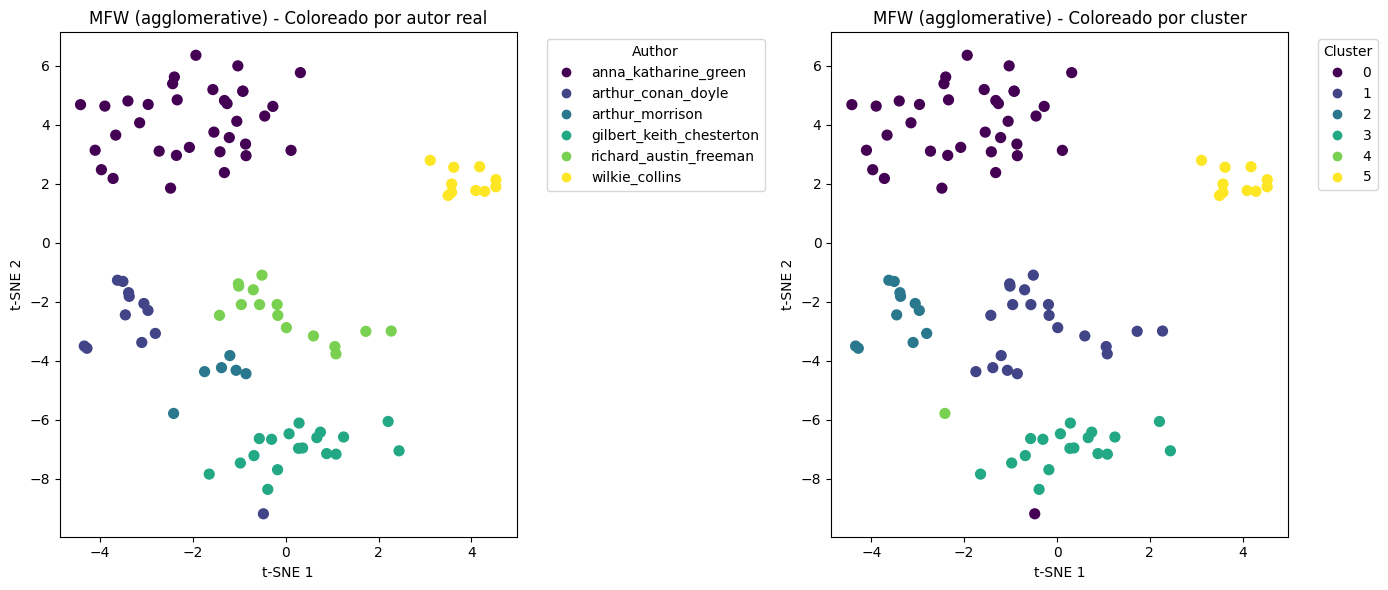

In [38]:
plot_clusters_2d(
    X_scaled=fw_cluster_result["X_scaled"],
    y_true=fw_cluster_result["y_true"],
    clusters=fw_clusters,
    title_prefix=f"MFW ({best_fw_model})",
    method="tsne",
    seed=SEED,
)

### Clústeres con features estilométricas + MFW

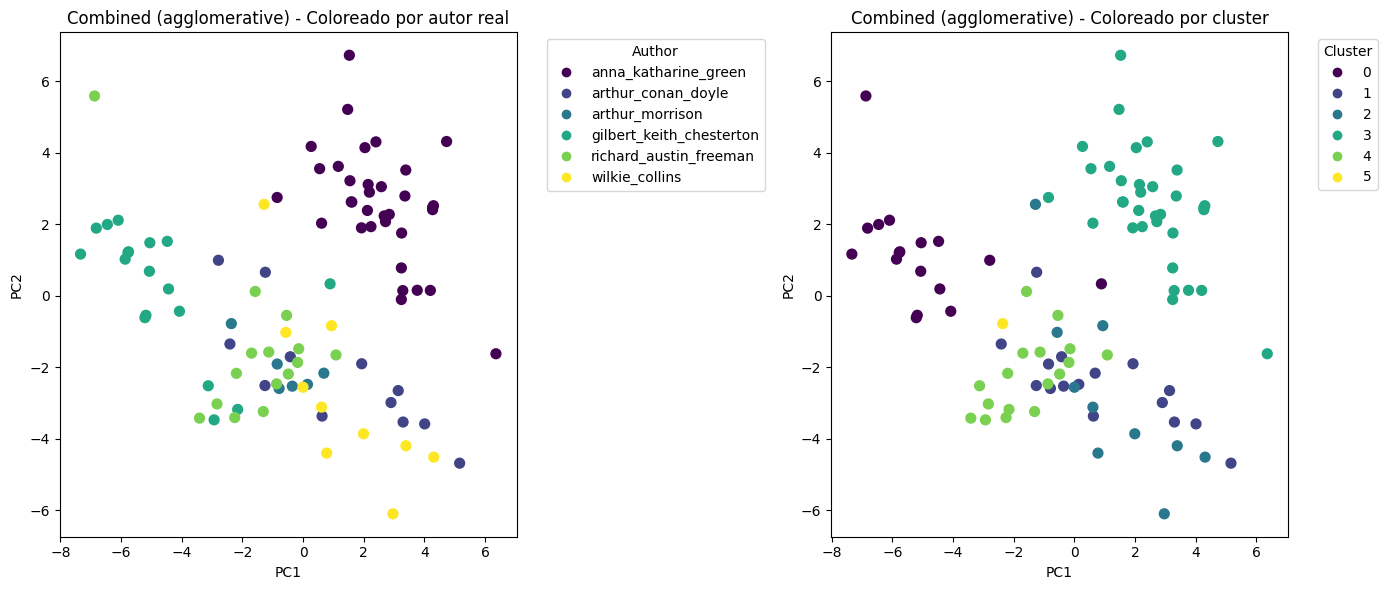

In [39]:
combined_clusters = combined_cluster_result["assignments"][best_combined_model]["cluster"].values

plot_clusters_2d(
    X_scaled=combined_cluster_result["X_scaled"],
    y_true=combined_cluster_result["y_true"],
    clusters=combined_clusters,
    title_prefix=f"Combined ({best_combined_model})",
    method="pca",
    seed=SEED,
)

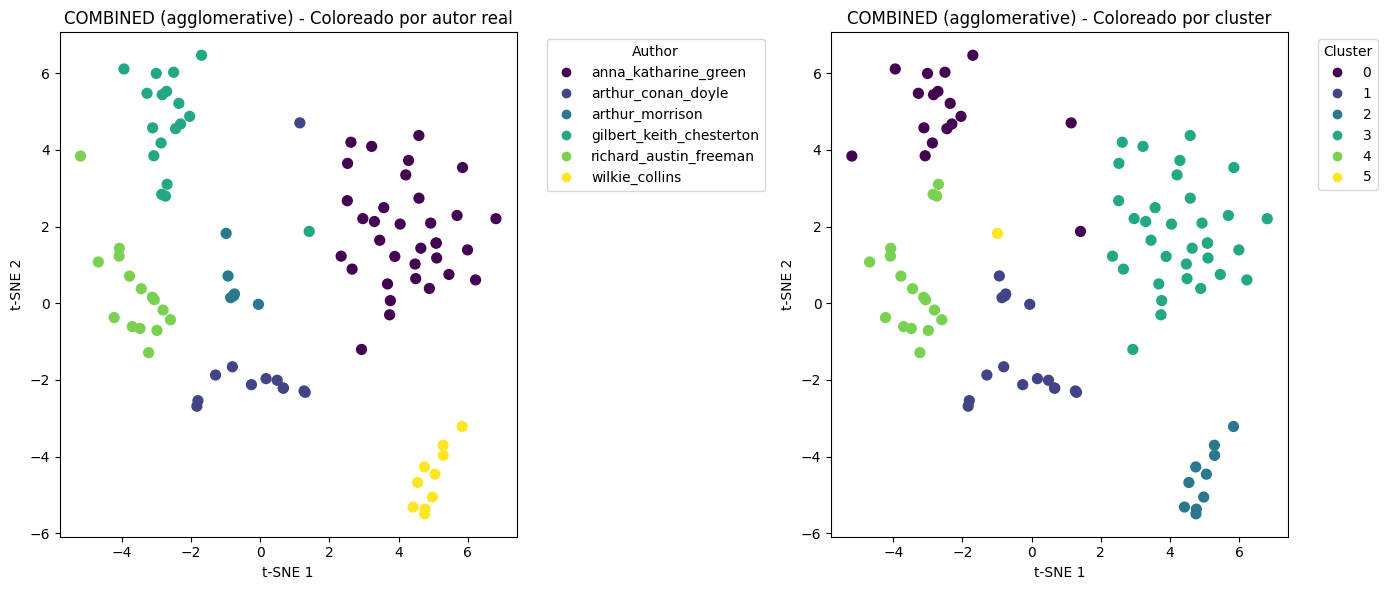

In [40]:
plot_clusters_2d(
    X_scaled=combined_cluster_result["X_scaled"],
    y_true=combined_cluster_result["y_true"],
    clusters=combined_clusters,
    title_prefix=f"COMBINED ({best_combined_model})",
    method="tsne",
    seed=SEED,
)

## Búsqueda de MFW óptimas para clustering

Repitiendo el experimento con diferentes semillas vemos que siempre es el modelo que usa solo MFW el que mejor funciona, aunque su rendimiento varía para el mismo número de features.

Pero con lo que sobre todo varía con el número de features de palabras funcionales que se eligen (`TOP_N_MFW`).

Vamos a realizar una búsqueda de los mejores `TOP_N_MFW` para el experimento de solo MFW, para lo que vamos a probar con diferentes valores de `TOP_N_MFW` y diferentes semillas para ver cómo afecta esto al rendimiento de los modelos.

In [41]:
# Espacio de búsqueda
SEEDS_TO_TEST = [0, 1, 2, 3, 4, 5, 10, 20, 42, 123, 150]
TOP_N_MFW_VALUES = [5, 10, 15, 25, 30, 40, 50, 75, 100, 125, 150]

In [42]:
grid_rows = []

for top_n, seed in product(TOP_N_MFW_VALUES, SEEDS_TO_TEST):
    print(f"Ejecutando experimento para TOP_N={top_n} y SEED={seed}...")

    # Construcción de MFW para ese TOP_N
    mfw, mfw_df_grid = build_mfw_features(
        tokens_by_file=tokens_by_file,
        function_words=STOPWORDS,
        top_n=top_n,
    )

    fw_cols_grid = [c for c in mfw_df_grid.columns if c.startswith("fw_")]

    fw_df_grid = df[["file_name", "author_norm"]].merge(
        mfw_df_grid[["file_name"] + fw_cols_grid], on="file_name", how="inner"
    )

    # Ejecutamos SOLO el experimento de function words
    result = run_clustering_experiment(
        data=fw_df_grid,
        feature_cols=fw_cols_grid,
        label_col="author_norm",
        file_col="file_name",
        seed=seed,
    )

    # Nos quedamos con los resultados por modelo
    tmp = result["results"].copy()
    tmp["top_n_mfw"] = top_n
    tmp["seed"] = seed
    tmp["n_features"] = len(fw_cols_grid)

    grid_rows.append(tmp)

Ejecutando experimento para TOP_N=5 y SEED=0...
Ejecutando experimento para TOP_N=5 y SEED=1...
Ejecutando experimento para TOP_N=5 y SEED=2...
Ejecutando experimento para TOP_N=5 y SEED=3...
Ejecutando experimento para TOP_N=5 y SEED=4...
Ejecutando experimento para TOP_N=5 y SEED=5...
Ejecutando experimento para TOP_N=5 y SEED=10...
Ejecutando experimento para TOP_N=5 y SEED=20...
Ejecutando experimento para TOP_N=5 y SEED=42...
Ejecutando experimento para TOP_N=5 y SEED=123...
Ejecutando experimento para TOP_N=5 y SEED=150...
Ejecutando experimento para TOP_N=10 y SEED=0...
Ejecutando experimento para TOP_N=10 y SEED=1...
Ejecutando experimento para TOP_N=10 y SEED=2...
Ejecutando experimento para TOP_N=10 y SEED=3...
Ejecutando experimento para TOP_N=10 y SEED=4...
Ejecutando experimento para TOP_N=10 y SEED=5...
Ejecutando experimento para TOP_N=10 y SEED=10...
Ejecutando experimento para TOP_N=10 y SEED=20...
Ejecutando experimento para TOP_N=10 y SEED=42...
Ejecutando experiment

In [43]:
# Concatenamos los resultados de todos
# los experimentos en un solo DataFrame
grid_results_df = pd.concat(grid_rows, ignore_index=True)

grid_results_df.sort_values(["ARI", "NMI", "silhouette"], ascending=False).head(20)

,model,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure,top_n_mfw,seed,n_features
264,kmeans,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,0,100
265,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,0,100
267,kmeans,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,1,100
268,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,1,100
270,kmeans,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,2,100
271,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,2,100
273,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,3,100
276,kmeans,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,4,100
277,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,4,100
278,gmm,6,0.257106,1.0,1.0,1.0,1.0,1.0,100,4,100


In [44]:
# Agregamos las métricas por cada valor de
# TOP_N_MFW y modelo para ver tendencias generales
summary_grid_df = grid_results_df.groupby(["top_n_mfw", "model"], as_index=False).agg(
    runs=("seed", "count"),
    mean_ARI=("ARI", "mean"),
    std_ARI=("ARI", "std"),
    min_ARI=("ARI", "min"),
    mean_NMI=("NMI", "mean"),
    std_NMI=("NMI", "std"),
    mean_silhouette=("silhouette", "mean"),
    std_silhouette=("silhouette", "std"),
    mean_homogeneity=("homogeneity", "mean"),
    mean_completeness=("completeness", "mean"),
    mean_v_measure=("v_measure", "mean"),
)

# Ordenamos por las métricas más relevantes para
# ver qué TOP_N_MFW tiende a funcionar mejor
summary_grid_df = summary_grid_df.sort_values(
    ["mean_ARI", "mean_NMI", "mean_silhouette", "top_n_mfw"], ascending=[False, False, False, True]
)

summary_grid_df.head(30)

,top_n_mfw,model,runs,mean_ARI,std_ARI,min_ARI,mean_NMI,std_NMI,mean_silhouette,std_silhouette,mean_homogeneity,mean_completeness,mean_v_measure
24,100,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.257106,0.000000,1.000000,1.000000,1.000000
27,125,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.247134,0.000000,1.000000,1.000000,1.000000
30,150,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.243370,0.000000,1.000000,1.000000,1.000000
29,125,kmeans,11,0.989203,0.022255,0.930161,0.989775,0.018964,0.246639,0.001082,0.987456,0.992238,0.989775
32,150,kmeans,11,0.987302,0.028251,0.930161,0.990184,0.021839,0.242338,0.002296,0.985402,0.995248,0.990184
26,100,kmeans,11,0.984392,0.031348,0.916021,0.984814,0.029240,0.253578,0.008588,0.984449,0.985186,0.984814
23,75,kmeans,11,0.930311,0.040661,0.831376,0.931434,0.043289,0.243367,0.009135,0.915725,0.948036,0.931434
21,75,agglomerative,11,0.927713,0.000000,0.927713,0.929527,0.000000,0.245758,0.000000,0.902434,0.958296,0.929527
18,50,agglomerative,11,0.919022,0.000000,0.919022,0.927689,0.000000,0.238272,0.000000,0.899107,0.958148,0.927689
12,30,agglomerative,11,0.872686,0.000000,0.872686,0.866534,0.000000,0.232069,0.000000,0.853977,0.879466,0.866534


In [45]:
# Nos quedamos con el mejor modelo por cada TOP_N_MFW
best_model_per_topn = (
    summary_grid_df.sort_values(
        ["top_n_mfw", "mean_ARI", "mean_NMI", "mean_silhouette"], ascending=[True, False, False, False]
    )
    .groupby("top_n_mfw", as_index=False)
    .first()
)

best_model_per_topn

,top_n_mfw,model,runs,mean_ARI,std_ARI,min_ARI,mean_NMI,std_NMI,mean_silhouette,std_silhouette,mean_homogeneity,mean_completeness,mean_v_measure
0,5,agglomerative,11,0.441462,0.000000,0.441462,0.587347,0.000000,0.211910,0.000000,0.602854,0.572617,0.587347
1,10,kmeans,11,0.493428,0.023959,0.441028,0.618641,0.027395,0.224318,0.004494,0.625081,0.612383,0.618641
2,15,agglomerative,11,0.531914,0.000000,0.531914,0.688013,0.000000,0.193898,0.000000,0.703242,0.673429,0.688013
3,25,gmm,11,0.680762,0.123432,0.450250,0.755467,0.064179,0.209864,0.016801,0.759350,0.752041,0.755467
4,30,agglomerative,11,0.872686,0.000000,0.872686,0.866534,0.000000,0.232069,0.000000,0.853977,0.879466,0.866534
5,40,gmm,11,0.702368,0.154163,0.438980,0.809278,0.073770,0.211578,0.019784,0.822118,0.797287,0.809278
6,50,agglomerative,11,0.919022,0.000000,0.919022,0.927689,0.000000,0.238272,0.000000,0.899107,0.958148,0.927689
7,75,kmeans,11,0.930311,0.040661,0.831376,0.931434,0.043289,0.243367,0.009135,0.915725,0.948036,0.931434
8,100,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.257106,0.000000,1.000000,1.000000,1.000000
9,125,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.247134,0.000000,1.000000,1.000000,1.000000


In [46]:
# Ordenamos siguiendo un criterio robusto:
#   - maximizar mean_ARI
#   - en empate, maximizar mean_NMI
#   - en empate, minimizar std_ARI
#   - y finalmente elegir el TOP_N_MFW más pequeño

best_topn_candidates = best_model_per_topn.sort_values(
    ["mean_ARI", "mean_NMI", "std_ARI", "top_n_mfw"], ascending=[False, False, True, True]
)

best_topn_candidates.head(10)

,top_n_mfw,model,runs,mean_ARI,std_ARI,min_ARI,mean_NMI,std_NMI,mean_silhouette,std_silhouette,mean_homogeneity,mean_completeness,mean_v_measure
8,100,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.257106,0.000000,1.000000,1.000000,1.000000
9,125,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.247134,0.000000,1.000000,1.000000,1.000000
10,150,agglomerative,11,1.000000,0.000000,1.000000,1.000000,0.000000,0.243370,0.000000,1.000000,1.000000,1.000000
7,75,kmeans,11,0.930311,0.040661,0.831376,0.931434,0.043289,0.243367,0.009135,0.915725,0.948036,0.931434
6,50,agglomerative,11,0.919022,0.000000,0.919022,0.927689,0.000000,0.238272,0.000000,0.899107,0.958148,0.927689
4,30,agglomerative,11,0.872686,0.000000,0.872686,0.866534,0.000000,0.232069,0.000000,0.853977,0.879466,0.866534
5,40,gmm,11,0.702368,0.154163,0.438980,0.809278,0.073770,0.211578,0.019784,0.822118,0.797287,0.809278
3,25,gmm,11,0.680762,0.123432,0.450250,0.755467,0.064179,0.209864,0.016801,0.759350,0.752041,0.755467
2,15,agglomerative,11,0.531914,0.000000,0.531914,0.688013,0.000000,0.193898,0.000000,0.703242,0.673429,0.688013
1,10,kmeans,11,0.493428,0.023959,0.441028,0.618641,0.027395,0.224318,0.004494,0.625081,0.612383,0.618641


In [47]:
# El mejor modelo para nuestro caso de uso sería el siguiente
best_choice = best_topn_candidates.iloc[0]

print("Mejor configuración encontrada:")
print(
    best_choice[
        [
            "top_n_mfw",
            "model",
            "mean_ARI",
            "std_ARI",
            "min_ARI",
            "mean_NMI",
            "std_NMI",
            "mean_silhouette",
            "std_silhouette",
        ]
    ]
)

Mejor configuración encontrada:
top_n_mfw                    100
model              agglomerative
mean_ARI                     1.0
std_ARI                      0.0
min_ARI                      1.0
mean_NMI                     1.0
std_NMI                      0.0
mean_silhouette         0.257106
std_silhouette               0.0
Name: 8, dtype: object


Ahora que hemos encontrado el modelo y el valor para `TOP_N_MFW` que nos da el mejor rendimiento, vamos a volver a ejecutar el experimento de solo MFW con este valor para ver si obtenemos un rendimiento similar al que obtuvimos con los modelos de aprendizaje supervisado.

In [48]:
BEST_TOP_N_MFW = 100
BEST_MODEL = "agglomerative"

# Construimos las features MFW con el TOP_N_MFW óptimo
mfw_best, mfw_best_df = build_mfw_features(
    tokens_by_file=tokens_by_file,
    function_words=STOPWORDS,
    top_n=BEST_TOP_N_MFW,
)

fw_best_cols = [c for c in mfw_best_df.columns if c.startswith("fw_")]

fw_best_df = base_df[["file_name", "author_norm"]].merge(
    mfw_best_df[["file_name"] + fw_best_cols], on="file_name", how="inner"
)

print("Shape del dataset MFW óptimo:", fw_best_df.shape)
print("Número de features MFW:", len(fw_best_cols))

Shape del dataset MFW óptimo: (95, 102)
Número de features MFW: 100


In [49]:
# Ejecutamos el experimento de clustering
best_cluster_result = run_clustering_experiment(
    data=fw_best_df,
    feature_cols=fw_best_cols,
    label_col="author_norm",
    file_col="file_name",
    seed=SEED,
)

# Vemos todos los modelos evaluados en esa ejecución
best_cluster_result["results"].sort_values(["ARI", "NMI", "silhouette"], ascending=False)

,model,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,kmeans,6,0.257106,1.000000,1.000000,1.00000,1.000000,1.000000
1,agglomerative,6,0.257106,1.000000,1.000000,1.00000,1.000000,1.000000
2,gmm,6,0.186655,0.731965,0.889934,0.91971,0.862026,0.889934


In [50]:
# Nos quedarnos con el modelo ganador concreto
best_model_row = best_cluster_result["results"].query("model == @BEST_MODEL").copy()

best_model_row

,model,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
1,agglomerative,6,0.257106,1.0,1.0,1.0,1.0,1.0


In [51]:
row = best_model_row.iloc[0]

print("Mejor configuración evaluada")
print("-" * 40)
print(f"Modelo          : {row['model']}")
print(f"N clusters      : {row['n_clusters']}")
print(f"Silhouette      : {row['silhouette']:.6f}")
print(f"ARI             : {row['ARI']:.6f}")
print(f"NMI             : {row['NMI']:.6f}")
print(f"Homogeneity     : {row['homogeneity']:.6f}")
print(f"Completeness    : {row['completeness']:.6f}")
print(f"V-measure       : {row['v_measure']:.6f}")

Mejor configuración evaluada
----------------------------------------
Modelo          : agglomerative
N clusters      : 6
Silhouette      : 0.257106
ARI             : 1.000000
NMI             : 1.000000
Homogeneity     : 1.000000
Completeness    : 1.000000
V-measure       : 1.000000


In [52]:
best_cluster_result.keys()

dict_keys(['results', 'assignments', 'X_scaled', 'y_true', 'label_encoder', 'feature_cols'])

In [53]:
# Sustituye `pred_labels` por el nombre real del vector de etiquetas predichas
pred_labels = best_cluster_result["assignments"][BEST_MODEL]["cluster"]

cluster_assignments_df = fw_best_df[["file_name", "author_norm"]].copy()
cluster_assignments_df["cluster"] = pred_labels

cluster_assignments_df.sort_values(["cluster", "author_norm", "file_name"])

,file_name,author_norm,cluster
46,am-adventures_of_martin_hewitt,arthur_morrison,0
47,am-chronicles_of_martin_hewitt,arthur_morrison,0
48,am-martin_hewitt_investigator,arthur_morrison,0
49,am-the_dorrington_deed_box,arthur_morrison,0
51,am-the_hole_in_the_wall,arthur_morrison,0
...,...,...,...
65,gkc-the_scandal_of_father_brown,gilbert_keith_chesterton,5
66,gkc-the_secret_of_father_brown,gilbert_keith_chesterton,5
67,gkc-the_trees_of_pride,gilbert_keith_chesterton,5
68,gkc-the_white_pillars_murder,gilbert_keith_chesterton,5


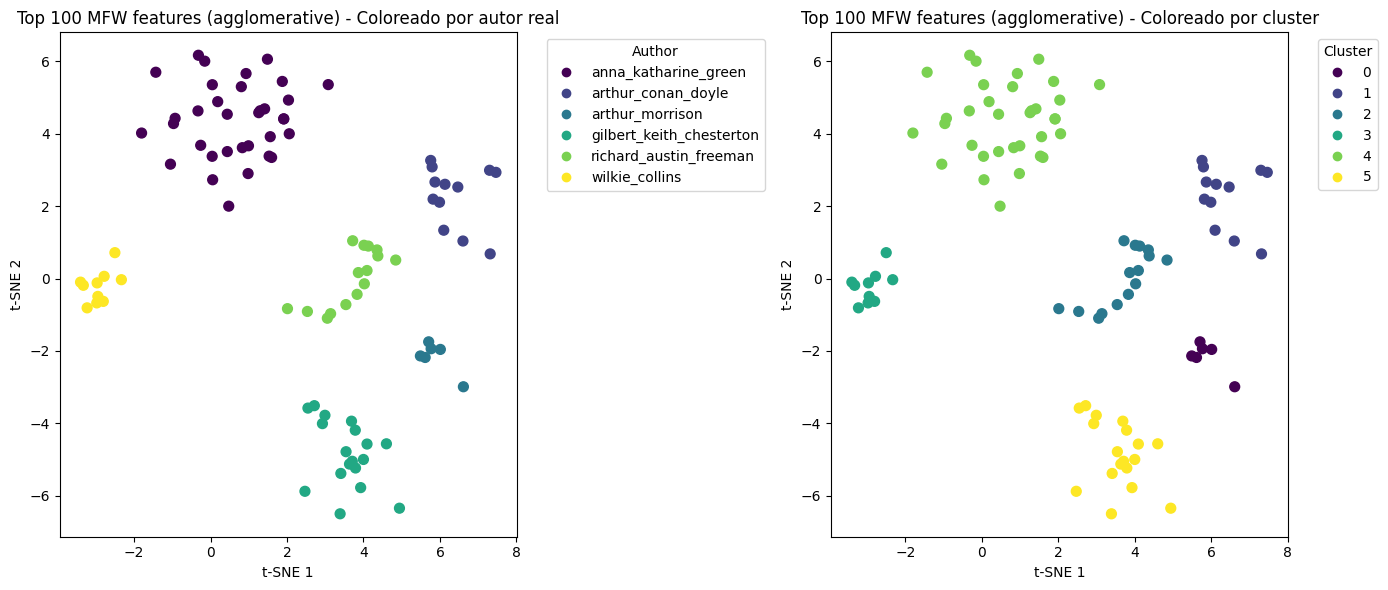

In [54]:
best_model_clusters = best_cluster_result["assignments"][BEST_MODEL]["cluster"].values

plot_clusters_2d(
    X_scaled=best_cluster_result["X_scaled"],
    y_true=best_cluster_result["y_true"],
    clusters=best_model_clusters,
    title_prefix=f"Top {BEST_TOP_N_MFW} MFW features ({BEST_MODEL})",
    method="tsne",
    seed=SEED,
)

Como vemos, el modelo de clustering con solo MFW y `TOP_N_MFW` igual a 100 obtiene un rendimiento bastante similar al que obtuvimos con los modelos de aprendizaje supervisado, lo que indica que estas características son muy efectivas para capturar el estilo de autoría y que el clustering es capaz de agrupar correctamente las obras por autor, aunque en este caso necesitamos usar un número sensiblemente mayor de características (100 vs 25 MFW) para obtener un rendimiento similar al de los modelos supervisados, lo que sugiere que el clustering puede requerir más información para lograr una buena separación entre los autores en comparación con los modelos supervisados.

# Clustering jerárquico

En esta sección aplicamos **clustering jerárquico aglomerativo** para explorar si las obras tienden a agruparse de manera natural según su autor a partir de las features extraídas. A diferencia de los modelos supervisados, este enfoque no utiliza `author_norm` para construir los grupos, sino únicamente las variables de entrada seleccionadas en cada experimento. El procedimiento parte de considerar cada obra como un clúster independiente y va fusionando iterativamente los pares más similares hasta formar una estructura jerárquica completa, representada mediante un dendrograma.

En nuestro caso, el método de enlace utilizado por defecto es Ward, que busca minimizar la varianza interna de los grupos en cada fusión y suele producir clústers compactos y bien definidos.

Aunque las etiquetas reales de autor no intervienen en el agrupamiento, sí se emplean en la visualización para colorear las hojas del dendrograma y comprobar visualmente hasta qué punto las obras de un mismo autor aparecen próximas entre sí.

### Features estilométricas

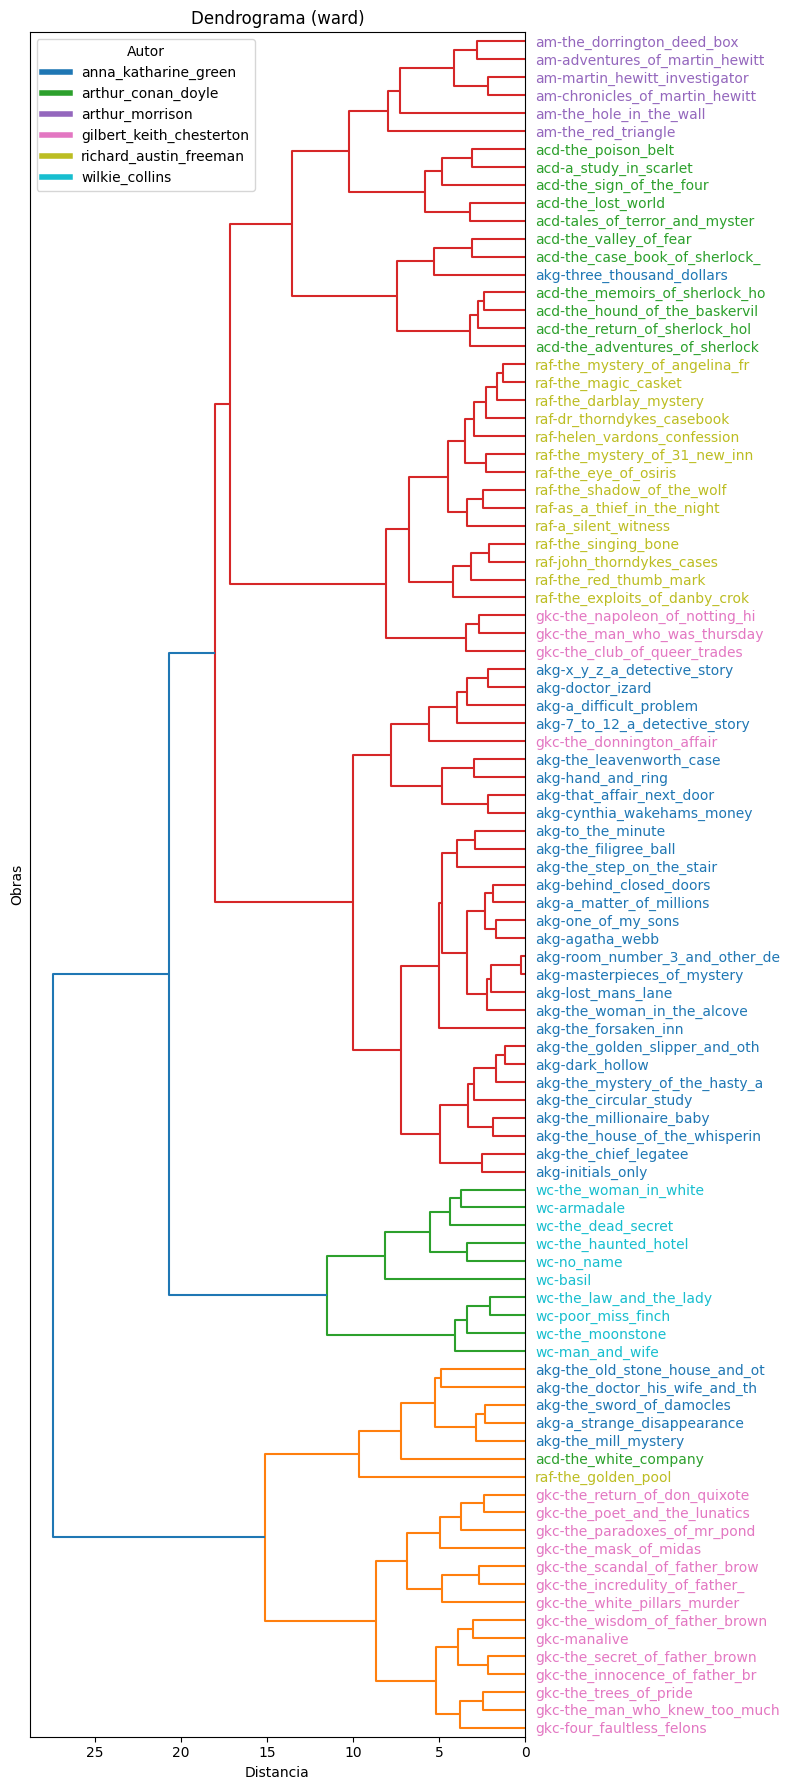

Dendrograma generado con 33 features estilométricas.


In [55]:
Z_base = plot_dendrogram_colored_labels(
    data=base_df,
    feature_cols=base_features,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    save_path=FIGS_DIR / "base_features_dendrogram.png",
)
print(f"Dendrograma generado con {len(base_features)} features estilométricas.")

### Features MFW

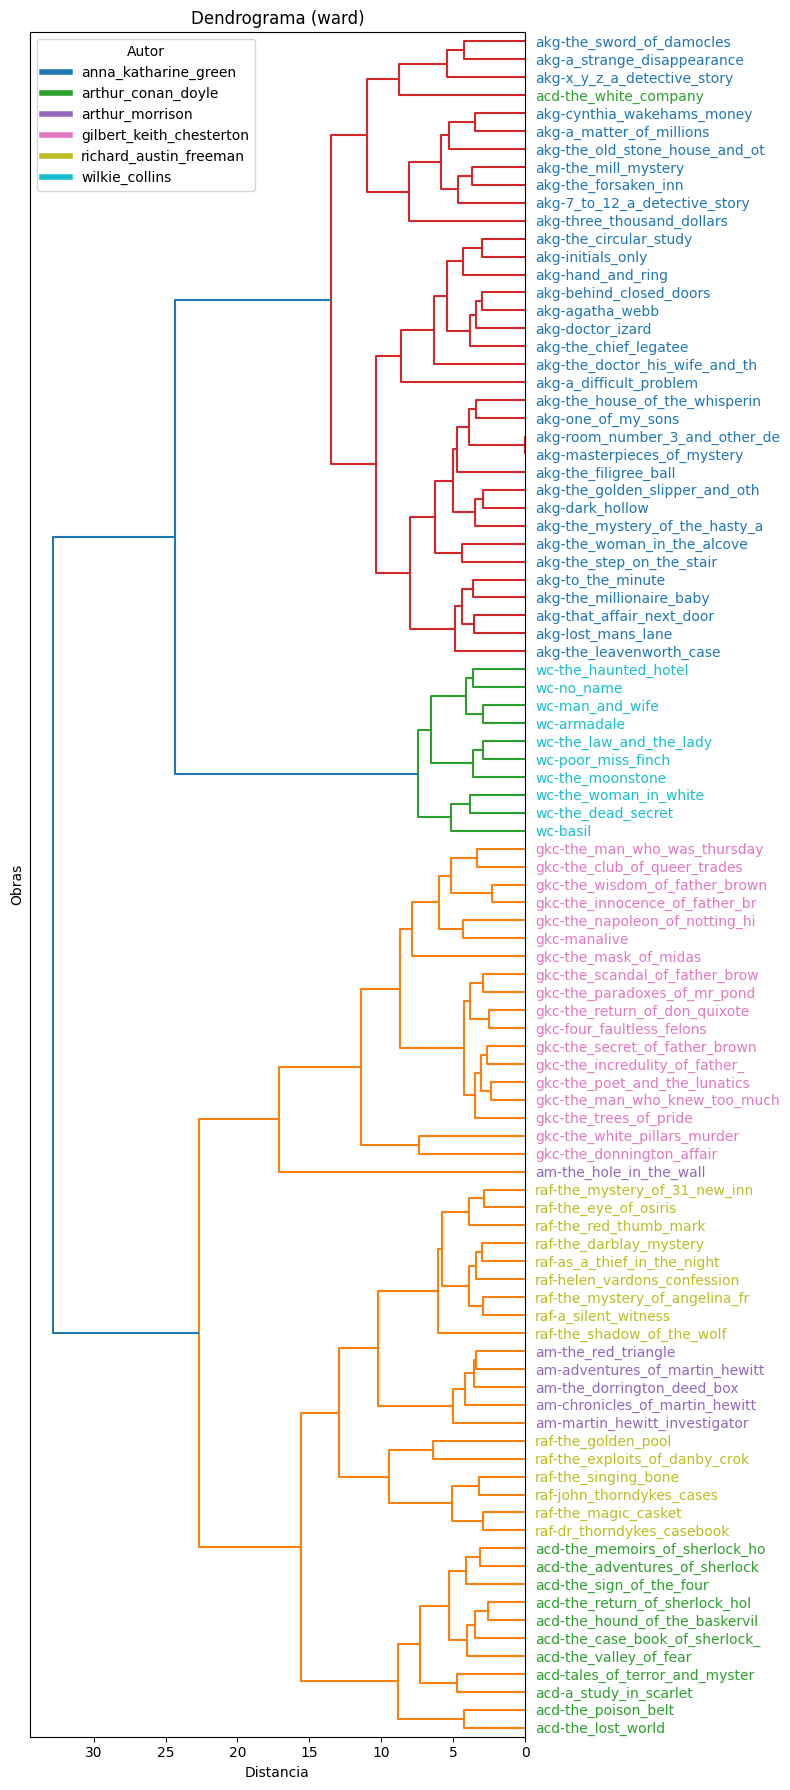

Dendrograma generado con 50 features MFW.


In [56]:
Z_fw = plot_dendrogram_colored_labels(
    data=fw_df,
    feature_cols=fw_cols,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    save_path=FIGS_DIR / "mfw_features_dendrogram.png",
)
print(f"Dendrograma generado con {len(fw_cols)} features MFW.")

### Features combinadas (estilométricas + MFW)

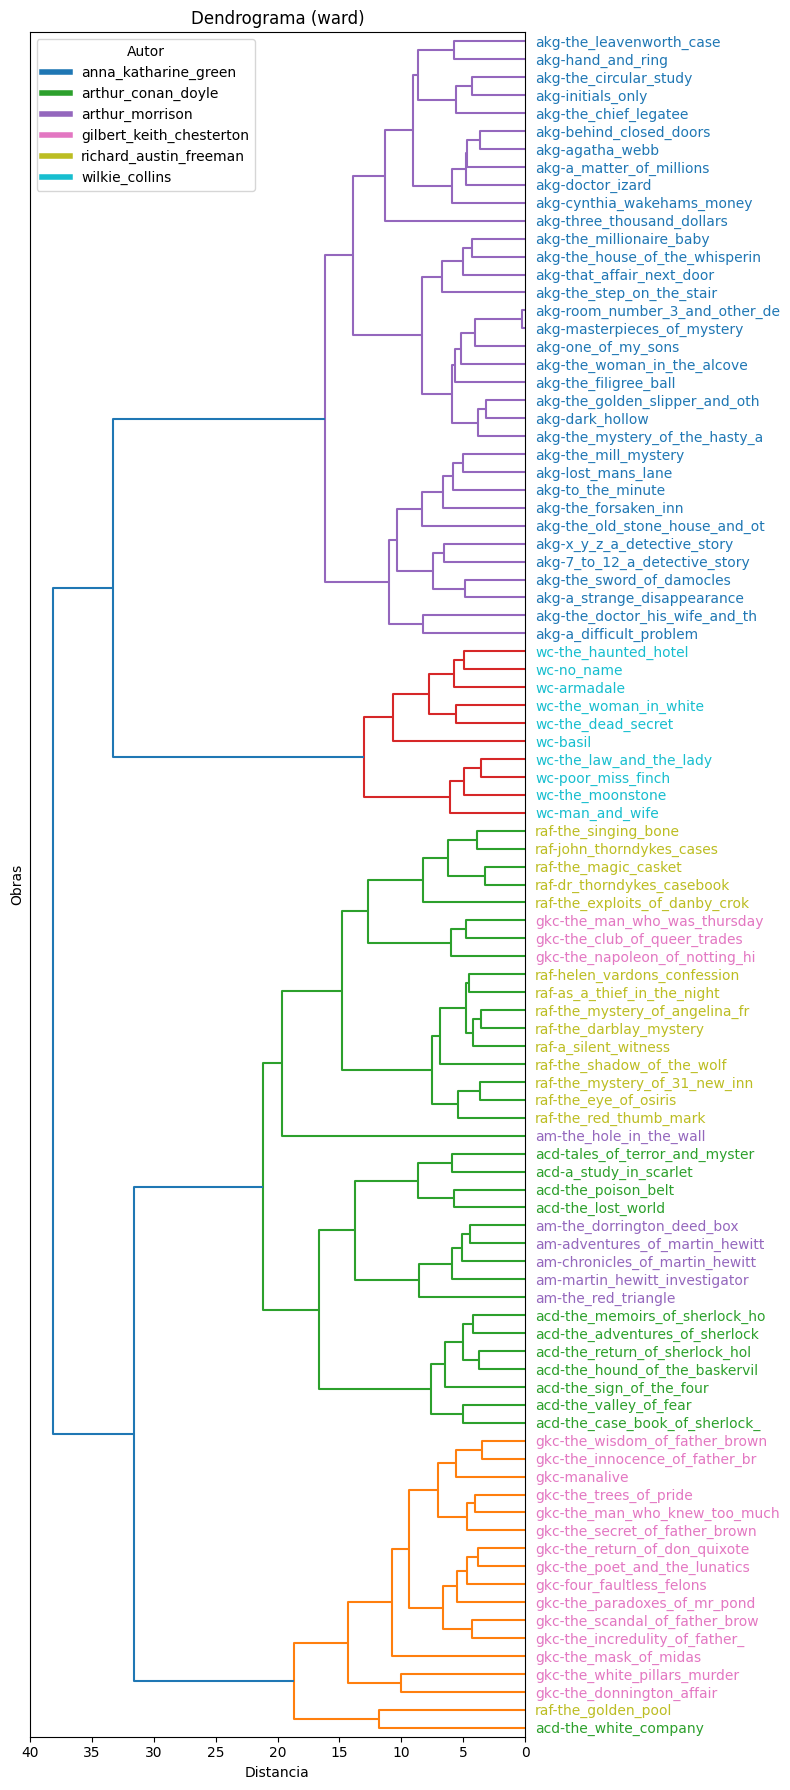

Dendrograma generado con 83 features combinadas.


In [57]:
Z_combined = plot_dendrogram_colored_labels(
    data=combined_df,
    feature_cols=base_features + fw_cols,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    save_path=FIGS_DIR / "combined_features_dendrogram.png",
)
print(f"Dendrograma generado con {len(base_features) + len(fw_cols)} features combinadas.")

## Evaluación de los clusters obtenidos con clustering jerárquico

Para evaluar la calidad de los clusters obtenidos con el clustering jerárquico, vamos a utilizar las mismas métricas que hemos utilizado para evaluar los clusters obtenidos con los otros algoritmos de clustering, es decir, ARI, NMI, homogeneity, completeness y V-measure. Estas métricas nos permitirán cuantificar la correspondencia entre los clusters obtenidos y las etiquetas reales de autor, y así poder comparar el rendimiento del clustering jerárquico con el de los otros algoritmos de clustering que hemos utilizado en este experimento.

In [58]:
hier_base = evaluate_hierarchical_clustering(
    data=base_df,
    feature_cols=base_features,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    n_clusters=base_df["author_norm"].nunique(),
)

hier_base["results"]

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.202401,0.706897,0.779033,0.790737,0.767669,0.779033


In [59]:
hier_fw = evaluate_hierarchical_clustering(
    data=fw_df,
    feature_cols=fw_cols,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    n_clusters=fw_df["author_norm"].nunique(),
)

hier_fw["results"]

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.238272,0.919022,0.927689,0.899107,0.958148,0.927689


In [60]:
hier_combined = evaluate_hierarchical_clustering(
    data=combined_df,
    feature_cols=base_features + fw_cols,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    n_clusters=combined_df["author_norm"].nunique(),
)

hier_combined["results"]

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.214542,0.866496,0.858151,0.837657,0.879673,0.858151


## Comparativa de diferentes métodos de agrupamiento jerárquico

Ahora vamos a comparar el rendimiento de los diferentes métodos de agrupamiento jerárquico utilizando la función `compare_hierarchical_clustering_methods`, que se encarga de ejecutar varios métodos de agrupamiento jerárquico sobre el mismo conjunto de datos y características, y luego evalúa la calidad de los clusters obtenidos con cada método utilizando las métricas seleccionadas.

Los métodos de agrupamiento jerárquico a evaluar son los siguientes:

- **Ward**. El método *ward* fusiona en cada paso los clústeres cuya unión produce el menor incremento posible en la varianza interna total. Suele generar grupos compactos y de tamaño relativamente equilibrado, aunque normalmente se utiliza con distancia euclídea.
- **Complete**. El método *complete linkage* calcula la distancia entre dos clústeres como la mayor distancia entre cualquier par de puntos pertenecientes a ambos grupos. Tiende a formar clústeres compactos y bien separados, pero puede ser sensible a puntos atípicos.
- **Average**. El método *average linkage* define la distancia entre dos clústeres como la distancia media entre todos los pares de puntos de ambos grupos. Es un criterio intermedio entre *single* y *complete*, y suele ofrecer agrupamientos más estables cuando no se quiere depender solo de las distancias extremas.
- **Single**. El método *single linkage* mide la distancia entre dos clústeres usando la menor distancia entre cualquier par de puntos de ambos grupos. Puede detectar estructuras alargadas o no esféricas, pero es sensible al efecto “cadena”, donde puntos cercanos van uniendo clústeres que deberían permanecer separados.

Como métrica, vamos a usar en todos los casos la distancia euclídea, que es la más comúnmente utilizada en clustering jerárquico y suele funcionar bien con datos numéricos como los que tenemos en este caso.

La distancia euclídea entre dos puntos $x$ e $y$ en un espacio de características se calcula como:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

In [61]:
compare_hierarchical_methods(data=base_df, feature_cols=base_features, label_col="author_norm", file_col="file_name")

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.202401,0.706897,0.779033,0.790737,0.767669,0.779033
1,complete,euclidean,6,0.154683,0.338856,0.500839,0.449817,0.564917,0.500839
2,average,euclidean,6,0.149752,0.135719,0.369494,0.245541,0.746172,0.369494
3,single,euclidean,6,0.110487,0.033402,0.131040,0.077092,0.436514,0.131040


In [62]:
compare_hierarchical_methods(data=fw_df, feature_cols=fw_cols, label_col="author_norm", file_col="file_name")

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.238272,0.919022,0.927689,0.899107,0.958148,0.927689
1,complete,euclidean,6,0.206669,0.515906,0.611402,0.517462,0.747013,0.611402
2,average,euclidean,6,0.143919,0.148510,0.389929,0.266786,0.724211,0.389929
3,single,euclidean,6,0.141935,0.142802,0.380358,0.255373,0.744950,0.380358


In [63]:
compare_hierarchical_methods(
    data=combined_df, feature_cols=base_features + fw_cols, label_col="author_norm", file_col="file_name"
)

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure
0,ward,euclidean,6,0.214542,0.866496,0.858151,0.837657,0.879673,0.858151
1,complete,euclidean,6,0.166586,0.491959,0.598783,0.558164,0.645777,0.598783
2,average,euclidean,6,0.139539,0.131533,0.374176,0.251223,0.732843,0.374176
3,single,euclidean,6,0.035089,0.021112,0.110266,0.064870,0.367311,0.110266


## Análisis de errores cometidos por el modelo de clustering jerárquico

In [64]:
hier_base_eval = evaluate_cluster_errors(
    hier_base["assignments"], label_col="author_norm", cluster_col="cluster", file_col="file_name"
)

print(f"Accuracy after mapping (Base): {hier_base_eval['accuracy_after_mapping']}")

Accuracy after mapping (Base): 0.8631578947368421


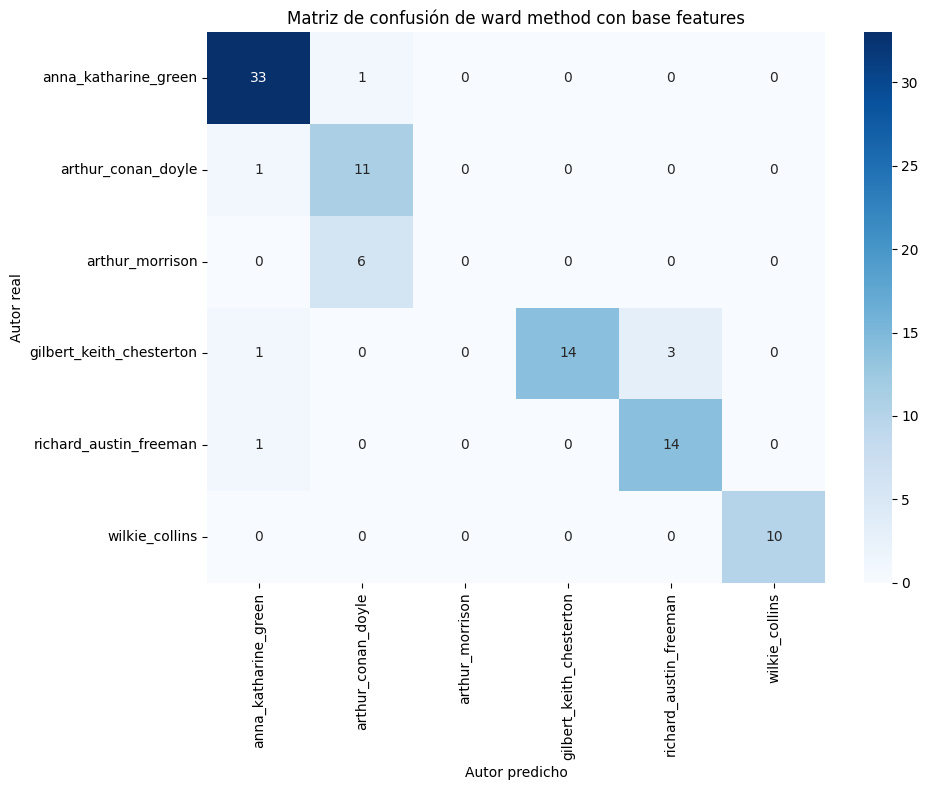

In [65]:
plot_confussion_matrix(
    cm=hier_base_eval["confusion_matrix"], labels=sorted(labels), model_name="ward method", features="base features"
)

In [66]:
hier_base_eval["errors_df"]

,file_name,author_norm,cluster,pred_author_from_cluster
43,akg-three_thousand_dollars,anna_katharine_green,6,arthur_conan_doyle
11,acd-the_white_company,arthur_conan_doyle,2,anna_katharine_green
46,am-adventures_of_martin_hewitt,arthur_morrison,6,arthur_conan_doyle
47,am-chronicles_of_martin_hewitt,arthur_morrison,6,arthur_conan_doyle
48,am-martin_hewitt_investigator,arthur_morrison,6,arthur_conan_doyle
49,am-the_dorrington_deed_box,arthur_morrison,6,arthur_conan_doyle
51,am-the_hole_in_the_wall,arthur_morrison,6,arthur_conan_doyle
50,am-the_red_triangle,arthur_morrison,6,arthur_conan_doyle
55,gkc-the_donnington_affair,gilbert_keith_chesterton,4,anna_katharine_green
54,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,5,richard_austin_freeman


In [67]:
hier_fw_eval = evaluate_cluster_errors(
    hier_fw["assignments"], label_col="author_norm", cluster_col="cluster", file_col="file_name"
)

print(f"Accuracy after mapping (FW): {hier_fw_eval['accuracy_after_mapping']}")

Accuracy after mapping (FW): 0.9368421052631579


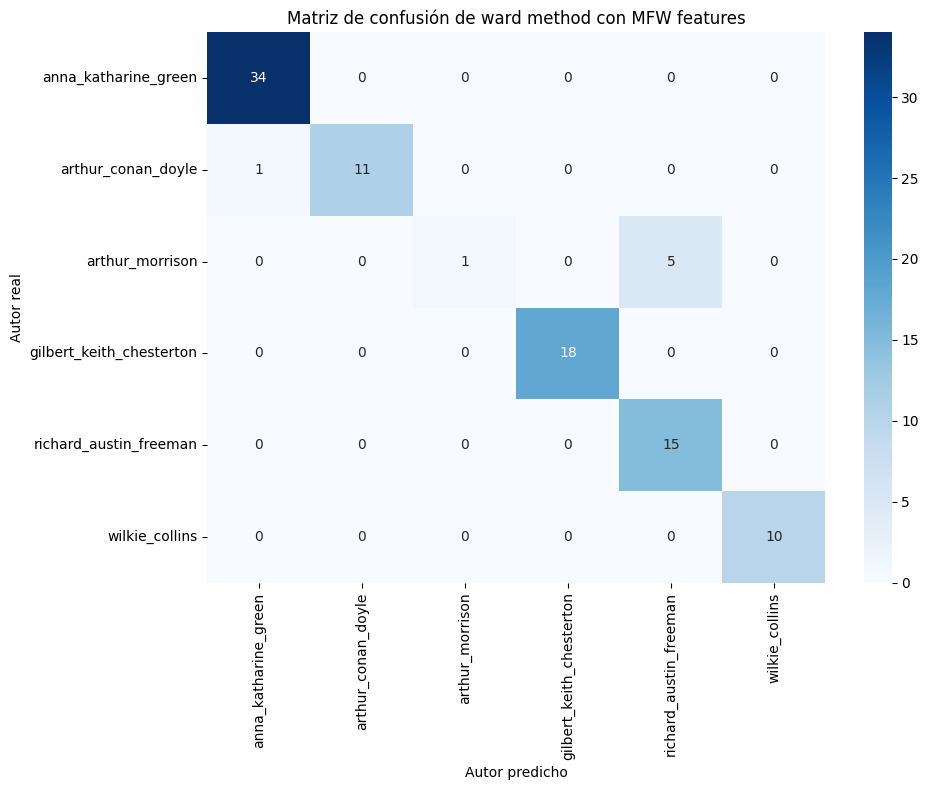

In [68]:
plot_confussion_matrix(
    cm=hier_fw_eval["confusion_matrix"], labels=sorted(labels), model_name="ward method", features="MFW features"
)

In [69]:
hier_fw_eval["errors_df"]

,file_name,author_norm,cluster,pred_author_from_cluster
11,acd-the_white_company,arthur_conan_doyle,6,anna_katharine_green
46,am-adventures_of_martin_hewitt,arthur_morrison,2,richard_austin_freeman
47,am-chronicles_of_martin_hewitt,arthur_morrison,2,richard_austin_freeman
48,am-martin_hewitt_investigator,arthur_morrison,2,richard_austin_freeman
49,am-the_dorrington_deed_box,arthur_morrison,2,richard_austin_freeman
50,am-the_red_triangle,arthur_morrison,2,richard_austin_freeman


In [70]:
hier_combined_eval = evaluate_cluster_errors(
    hier_combined["assignments"], label_col="author_norm", cluster_col="cluster", file_col="file_name"
)

print(f"Accuracy after mapping (Combined): {hier_combined_eval['accuracy_after_mapping']}")

Accuracy after mapping (Combined): 0.8947368421052632


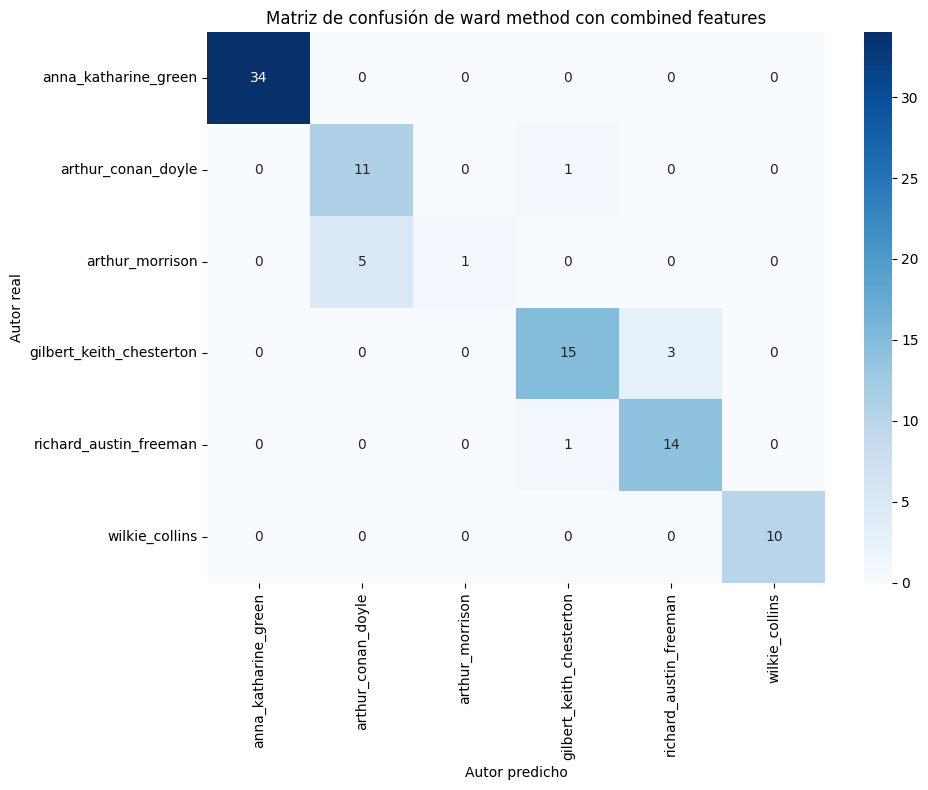

In [71]:
plot_confussion_matrix(
    cm=hier_combined_eval["confusion_matrix"],
    labels=sorted(labels),
    model_name="ward method",
    features="combined features",
)

In [72]:
hier_combined_eval["errors_df"].head(20)

,file_name,author_norm,cluster,pred_author_from_cluster
11,acd-the_white_company,arthur_conan_doyle,1,gilbert_keith_chesterton
46,am-adventures_of_martin_hewitt,arthur_morrison,2,arthur_conan_doyle
47,am-chronicles_of_martin_hewitt,arthur_morrison,2,arthur_conan_doyle
48,am-martin_hewitt_investigator,arthur_morrison,2,arthur_conan_doyle
49,am-the_dorrington_deed_box,arthur_morrison,2,arthur_conan_doyle
50,am-the_red_triangle,arthur_morrison,2,arthur_conan_doyle
54,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,3,richard_austin_freeman
59,gkc-the_man_who_was_thursday,gilbert_keith_chesterton,3,richard_austin_freeman
61,gkc-the_napoleon_of_notting_hill,gilbert_keith_chesterton,3,richard_austin_freeman
78,raf-the_golden_pool,richard_austin_freeman,1,gilbert_keith_chesterton


Concatenando los resultados de los tres experimentos para quedarnos con el mejor modelo de cada experimento, es decir, con el modelo que haya obtenido la mejor puntuación en la métrica de evaluación seleccionada (en este caso, el ARI).

In [73]:
hier_summary = pd.concat(
    [
        hier_base["results"].assign(experiment="base"),
        hier_fw["results"].assign(experiment="mfw"),
        hier_combined["results"].assign(experiment="combined"),
    ],
    ignore_index=True,
)

hier_summary.sort_values(["ARI", "NMI", "silhouette"], ascending=False)

,method,metric,n_clusters,silhouette,ARI,NMI,homogeneity,completeness,v_measure,experiment
1,ward,euclidean,6,0.238272,0.919022,0.927689,0.899107,0.958148,0.927689,mfw
2,ward,euclidean,6,0.214542,0.866496,0.858151,0.837657,0.879673,0.858151,combined
0,ward,euclidean,6,0.202401,0.706897,0.779033,0.790737,0.767669,0.779033,base


## Clustering jerárquico con MFW óptimas

Cómo hemos visto, el modelo que mejor rendimiento ha obtenido es el modelo de clustering con solo MFW, y el valor de `TOP_N_MFW` que nos ha dado el mejor rendimiento es 100. Por lo tanto, vamos a volver a ejecutar el experimento de clustering jerárquico con solo MFW usando este valor de `TOP_N_MFW` para ver si se confirma el resultado.

In [74]:
print("Shape del dataset MFW óptimo:", fw_best_df.shape)
print("Número de features MFW óptimo: ", len(fw_best_cols))

Shape del dataset MFW óptimo: (95, 102)
Número de features MFW óptimo:  100


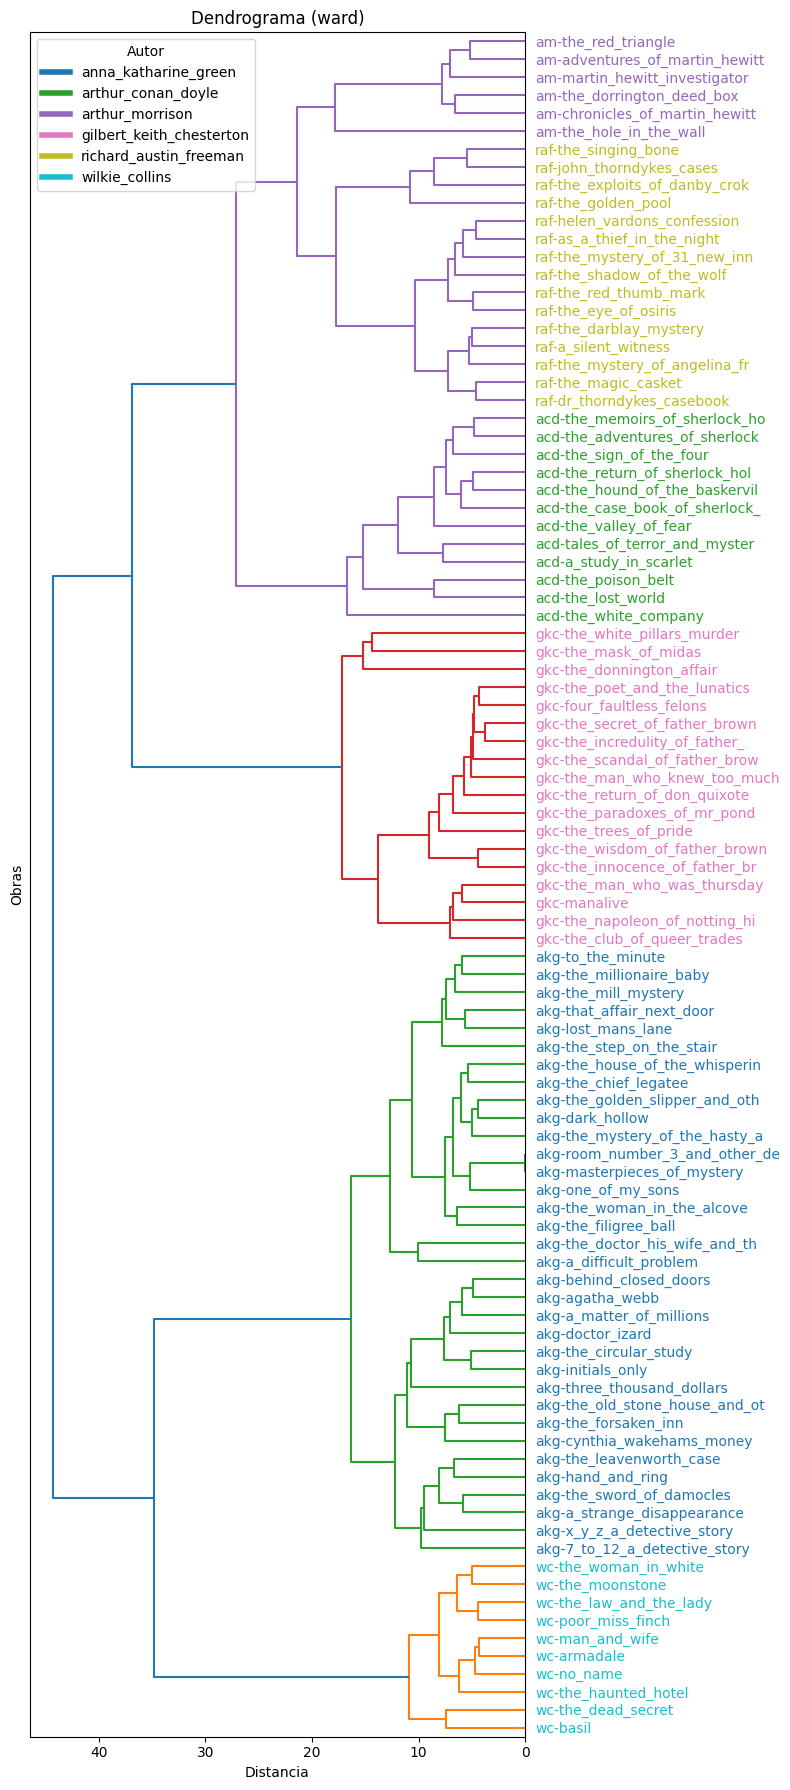

Dendrograma generado con 100 features MFW.


In [75]:
Z_best_fw = plot_dendrogram_colored_labels(
    data=fw_best_df,
    feature_cols=fw_best_cols,
    label_col="author_norm",
    file_col="file_name",
    method="ward",
    save_path=FIGS_DIR / "mfw_features_dendrogram.png",
)
print(f"Dendrograma generado con {len(fw_best_cols)} features MFW.")

Comprobamos que efectivamente el modelo de clustering jerárquico con solo MFW y `TOP_N_MFW` igual a 100 obtiene un rendimiento óptimo siendo capaz de agrupar correctamente todas las obras por autor.